In [ ]:
!pip install flask

# 两个模型单独训练 后续进行融合

音乐情感分析系统 - 模型训练

1. 加载中文歌词数据
成功加载 1600 条歌词数据
清洗后: 1600 条有效数据

类别分布:
  happy: 400 (25.0%)
  sad: 400 (25.0%)
  calm: 400 (25.0%)
  energetic: 400 (25.0%)

2. 训练歌词情感分析模型

提取歌词特征...
特征矩阵: (1600, 10)
标签数量: 1600
情感类别: [np.str_('calm'), np.str_('energetic'), np.str_('happy'), np.str_('sad')]

处理数据不平衡...
训练集类别分布:
  calm: 320 样本
  energetic: 320 样本
  happy: 320 样本
  sad: 320 样本
使用SMOTE过采样...
平衡后训练集: 1280 样本

训练和评估模型:
  RandomForest: 0.841
  GradientBoosting: 0.844
  LogisticRegression: 0.675

最佳模型: GradientBoosting
准确率: 0.844

分类报告:
              precision    recall  f1-score   support

        calm       0.70      0.75      0.72        80
   energetic       0.87      0.93      0.90        80
       happy       1.00      1.00      1.00        80
         sad       0.81      0.70      0.75        80

    accuracy                           0.84       320
   macro avg       0.84      0.84      0.84       320
weighted avg       0.84      0.84      0.84       320


保存歌词模型...
歌词模型已保存到 models 目录

3. 

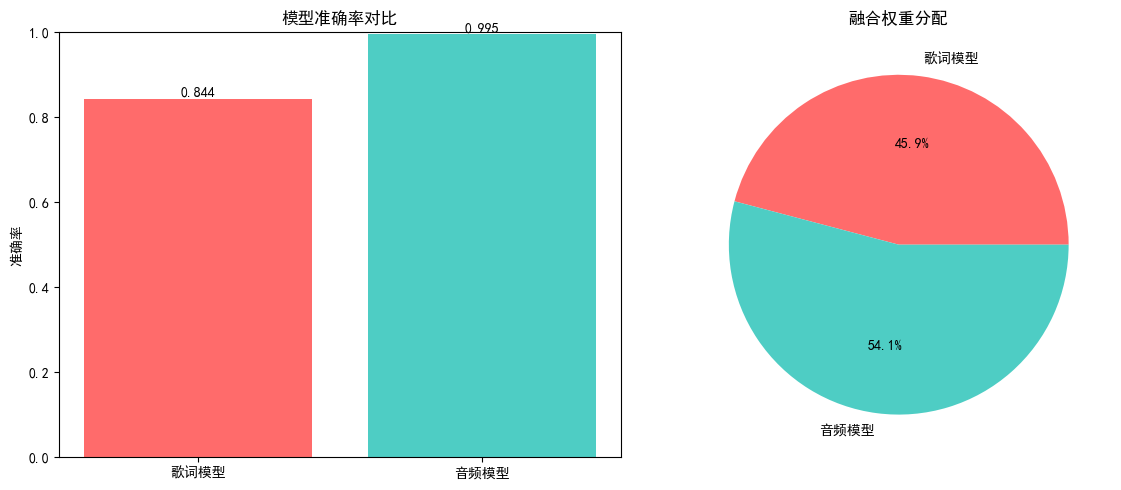


结果图表已保存到 models/training_results.png

训练完成总结
歌词模型准确率: 0.844
音频模型准确率: 0.995

融合权重:
  歌词权重: 0.459
  音频权重: 0.541

模型保存位置: models/

已保存的模型文件:
  - audio_encoder.pkl
  - audio_info.pkl
  - audio_model.pkl
  - audio_scaler.pkl
  - lyrics_encoder.pkl
  - lyrics_info.pkl
  - lyrics_model.pkl
  - lyrics_scaler.pkl
  - training_results.png


In [13]:
# train_models.py - 训练歌词和音频模型
import pandas as pd
import numpy as np
import pickle
import joblib
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE, RandomOverSampler
import jieba
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ======================== 配置 ========================

MODEL_DIR = 'models'
#LYRICS_DATA = 'processed_chinese_lyrics_full.csv'
LYRICS_DATA ='balanced_multimodal_dataset.csv'
AUDIO_DATA = 'music_emotion_dataset.csv'

def ensure_model_dir():
    """确保模型目录存在"""
    if not os.path.exists(MODEL_DIR):
        os.makedirs(MODEL_DIR)
        print(f"创建模型目录: {MODEL_DIR}")

# ======================== 歌词模型训练 ========================

class LyricsModelTrainer:
    """中文歌词情感分析模型训练器"""
    
    def __init__(self):
        self.model = None
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.feature_names = []
        self.performance = {}
        
    def load_data(self):
        """加载歌词数据"""
        print("\n" + "="*60)
        print("1. 加载中文歌词数据")
        print("="*60)
        
        try:
            self.data = pd.read_csv(LYRICS_DATA, encoding='utf-8')
            print(f"成功加载 {len(self.data)} 条歌词数据")
            
            # 数据清洗 - 只保留有情感标签的数据
            self.data = self.data.dropna(subset=['emotion_label'])
            print(f"清洗后: {len(self.data)} 条有效数据")
            
            # 分析类别分布
            print("\n类别分布:")
            distribution = self.data['emotion_label'].value_counts()
            for emotion, count in distribution.items():
                print(f"  {emotion}: {count} ({count/len(self.data)*100:.1f}%)")
            
            return True
            
        except Exception as e:
            print(f"加载数据失败: {e}")
            return False
    
    def extract_features(self, text):
        """提取歌词特征"""
        if pd.isna(text) or text == '':
            return np.zeros(10)
        
        # 分词
        words = list(jieba.cut(str(text)))
        
        # 情感词典
        positive_words = ['快乐', '开心', '幸福', '美好', '爱', '喜欢', '温暖', '阳光', 
                         '甜蜜', '浪漫', '欢乐', '愉快', '美丽', '希望', '梦想']
        negative_words = ['悲伤', '痛苦', '难过', '孤独', '寂寞', '失落', '眼泪', '分离',
                         '伤心', '离别', '痛', '哭', '失去', '绝望', '黑暗']
        calm_words = ['平静', '安宁', '宁静', '淡然', '从容', '舒适', '轻松', '安详',
                     '静谧', '恬静', '悠闲', '平和', '安静', '清净']
        energetic_words = ['激情', '热血', '奔跑', '飞翔', '疯狂', '燃烧', '冲动', '狂欢',
                          '热烈', '澎湃', '激动', '兴奋', '活力', '强烈']
        
        # 计算特征
        total_words = len(words) if words else 1
        
        features = [
            len(text),  # 文本长度
            len(words),  # 词数
            len(set(words)),  # 独特词数
            len(set(words)) / total_words,  # 词汇多样性
            sum(1 for w in words if w in positive_words) / total_words,  # 正面词比例
            sum(1 for w in words if w in negative_words) / total_words,  # 负面词比例
            sum(1 for w in words if w in calm_words) / total_words,  # 平静词比例
            sum(1 for w in words if w in energetic_words) / total_words,  # 活力词比例
            np.mean([len(w) for w in words]) if words else 0,  # 平均词长
            sum(1 for w in words if len(w) > 2) / total_words  # 长词比例
        ]
        
        return np.array(features)
    
    def prepare_features(self):
        """准备训练特征"""
        print("\n提取歌词特征...")
        
        X = []
        y = []
        
        for idx, row in self.data.iterrows():
            if pd.notna(row.get('emotion_label')):
                # 尝试多个可能的歌词列名
                lyrics_text = row.get('lyrics', row.get('processed_clean_text', row.get('text', '')))
                features = self.extract_features(lyrics_text)
                
                X.append(features)
                y.append(row['emotion_label'])
        
        X = np.array(X)
        y = self.label_encoder.fit_transform(y)
        
        self.feature_names = [
            'text_length', 'word_count', 'unique_words', 'vocabulary_diversity',
            'positive_ratio', 'negative_ratio', 'calm_ratio', 'energetic_ratio',
            'avg_word_length', 'long_word_ratio'
        ]
        
        print(f"特征矩阵: {X.shape}")
        print(f"标签数量: {len(y)}")
        print(f"情感类别: {list(self.label_encoder.classes_)}")
        
        return X, y
    
    def handle_imbalance(self, X_train, y_train):
        """处理数据不平衡"""
        print("\n处理数据不平衡...")
        
        unique, counts = np.unique(y_train, return_counts=True)
        min_samples = min(counts)
        
        print("训练集类别分布:")
        for label, count in zip(unique, counts):
            emotion = self.label_encoder.inverse_transform([label])[0]
            print(f"  {emotion}: {count} 样本")
        
        if min_samples < 20:
            print("使用随机过采样...")
            ros = RandomOverSampler(random_state=42)
            X_balanced, y_balanced = ros.fit_resample(X_train, y_train)
        elif min_samples >= 6:
            print("使用SMOTE过采样...")
            smote = SMOTE(random_state=42, k_neighbors=min(5, min_samples-1))
            X_balanced, y_balanced = smote.fit_resample(X_train, y_train)
        else:
            print("样本太少，使用原始数据...")
            X_balanced, y_balanced = X_train, y_train
        
        print(f"平衡后训练集: {len(X_balanced)} 样本")
        return X_balanced, y_balanced
    
    def train(self):
        """训练模型"""
        print("\n" + "="*60)
        print("2. 训练歌词情感分析模型")
        print("="*60)
        
        # 准备数据
        X, y = self.prepare_features()
        
        # 标准化
        X_scaled = self.scaler.fit_transform(X)
        
        # 分割数据
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42, stratify=y
        )
        
        # 处理不平衡
        X_train_balanced, y_train_balanced = self.handle_imbalance(X_train, y_train)
        
        # 训练多个模型
        models = {
            'RandomForest': RandomForestClassifier(
                n_estimators=100, max_depth=10, random_state=42
            ),
            'GradientBoosting': GradientBoostingClassifier(
                n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
            ),
            'LogisticRegression': LogisticRegression(
                max_iter=1000, random_state=42
            )
        }
        
        best_score = 0
        best_model_name = ''
        
        print("\n训练和评估模型:")
        for name, model in models.items():
            model.fit(X_train_balanced, y_train_balanced)
            y_pred = model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            
            print(f"  {name}: {accuracy:.3f}")
            
            if accuracy > best_score:
                best_score = accuracy
                best_model_name = name
                self.model = model
        
        # 详细评估
        y_pred = self.model.predict(X_test)
        
        print(f"\n最佳模型: {best_model_name}")
        print(f"准确率: {best_score:.3f}")
        
        print("\n分类报告:")
        print(classification_report(
            y_test, y_pred,
            target_names=self.label_encoder.classes_
        ))
        
        # 保存性能指标
        self.performance = {
            'accuracy': best_score,
            'test_size': len(X_test),
            'train_size': len(X_train_balanced),
            'model_type': best_model_name,
            'n_features': len(self.feature_names),
            'n_classes': len(self.label_encoder.classes_)
        }
        
        return best_score
    
    def save_model(self):
        """保存模型"""
        ensure_model_dir()
        
        print("\n保存歌词模型...")
        
        # 保存模型组件
        joblib.dump(self.model, os.path.join(MODEL_DIR, 'lyrics_model.pkl'))
        joblib.dump(self.scaler, os.path.join(MODEL_DIR, 'lyrics_scaler.pkl'))
        joblib.dump(self.label_encoder, os.path.join(MODEL_DIR, 'lyrics_encoder.pkl'))
        
        # 保存特征信息和性能
        with open(os.path.join(MODEL_DIR, 'lyrics_info.pkl'), 'wb') as f:
            pickle.dump({
                'feature_names': self.feature_names,
                'performance': self.performance,
                'timestamp': datetime.now().isoformat()
            }, f)
        
        print(f"歌词模型已保存到 {MODEL_DIR} 目录")

# ======================== 音频模型训练 ========================

class AudioModelTrainer:
    """音频特征情感分析模型训练器"""
    
    def __init__(self):
        self.model = None
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.feature_names = []
        self.performance = {}
    
    def load_data(self):
        """加载音频数据"""
        print("\n" + "="*60)
        print("3. 加载音频特征数据")
        print("="*60)
        
        try:
            self.data = pd.read_csv(AUDIO_DATA)
            print(f"成功加载 {len(self.data)} 条音频数据")
            
            # 分析类别分布
            print("\n类别分布:")
            distribution = self.data['emotion_label'].value_counts()
            for emotion, count in distribution.items():
                print(f"  {emotion}: {count} ({count/len(self.data)*100:.1f}%)")
            
            return True
            
        except Exception as e:
            print(f"加载数据失败: {e}")
            return False
    
    def prepare_features(self):
        """准备音频特征"""
        print("\n准备音频特征...")
        
        # 音频特征列
        self.feature_names = [
            'valence', 'energy', 'danceability', 'tempo',
            'loudness', 'acousticness', 'instrumentalness',
            'speechiness', 'liveness'
        ]
        
        # 提取特征和标签
        X = self.data[self.feature_names].fillna(0).values
        y = self.label_encoder.fit_transform(self.data['emotion_label'])
        
        print(f"特征矩阵: {X.shape}")
        print(f"标签数量: {len(y)}")
        print(f"情感类别: {list(self.label_encoder.classes_)}")
        
        return X, y
    
    def train(self):
        """训练音频模型"""
        print("\n" + "="*60)
        print("4. 训练音频情感分析模型")
        print("="*60)
        
        # 准备数据
        X, y = self.prepare_features()
        
        # 标准化
        X_scaled = self.scaler.fit_transform(X)
        
        # 分割数据
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42, stratify=y
        )
        
        print(f"训练集: {len(X_train)} 样本")
        print(f"测试集: {len(X_test)} 样本")
        
        # 训练多个模型
        models = {
            'RandomForest': RandomForestClassifier(
                n_estimators=150, max_depth=12, random_state=42
            ),
            'GradientBoosting': GradientBoostingClassifier(
                n_estimators=120, learning_rate=0.1, max_depth=6, random_state=42
            )
        }
        
        best_score = 0
        best_model_name = ''
        
        print("\n训练和评估模型:")
        for name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            
            print(f"  {name}: {accuracy:.3f}")
            
            if accuracy > best_score:
                best_score = accuracy
                best_model_name = name
                self.model = model
        
        # 详细评估
        y_pred = self.model.predict(X_test)
        
        print(f"\n最佳模型: {best_model_name}")
        print(f"准确率: {best_score:.3f}")
        
        print("\n分类报告:")
        print(classification_report(
            y_test, y_pred,
            target_names=self.label_encoder.classes_
        ))
        
        # 特征重要性
        if hasattr(self.model, 'feature_importances_'):
            importance = pd.DataFrame({
                'feature': self.feature_names,
                'importance': self.model.feature_importances_
            }).sort_values('importance', ascending=False)
            
            print("\n特征重要性 Top 5:")
            for _, row in importance.head(5).iterrows():
                print(f"  {row['feature']}: {row['importance']:.3f}")
        
        # 保存性能指标
        self.performance = {
            'accuracy': best_score,
            'test_size': len(X_test),
            'train_size': len(X_train),
            'model_type': best_model_name,
            'n_features': len(self.feature_names),
            'n_classes': len(self.label_encoder.classes_)
        }
        
        return best_score
    
    def save_model(self):
        """保存模型"""
        ensure_model_dir()
        
        print("\n保存音频模型...")
        
        # 保存模型组件
        joblib.dump(self.model, os.path.join(MODEL_DIR, 'audio_model.pkl'))
        joblib.dump(self.scaler, os.path.join(MODEL_DIR, 'audio_scaler.pkl'))
        joblib.dump(self.label_encoder, os.path.join(MODEL_DIR, 'audio_encoder.pkl'))
        
        # 保存特征信息和性能
        with open(os.path.join(MODEL_DIR, 'audio_info.pkl'), 'wb') as f:
            pickle.dump({
                'feature_names': self.feature_names,
                'performance': self.performance,
                'timestamp': datetime.now().isoformat()
            }, f)
        
        print(f"音频模型已保存到 {MODEL_DIR} 目录")

# ======================== 可视化 ========================

def plot_results(lyrics_acc, audio_acc):
    """绘制训练结果"""
    plt.figure(figsize=(12, 5))
    
    # 准确率对比
    plt.subplot(1, 2, 1)
    models = ['歌词模型', '音频模型']
    accuracies = [lyrics_acc, audio_acc]
    colors = ['#FF6B6B', '#4ECDC4']
    
    bars = plt.bar(models, accuracies, color=colors)
    plt.ylabel('准确率')
    plt.title('模型准确率对比')
    plt.ylim([0, 1])
    
    # 添加数值标签
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.3f}', ha='center', va='bottom')
    
    # 融合权重
    plt.subplot(1, 2, 2)
    total = lyrics_acc + audio_acc
    weights = [lyrics_acc/total, audio_acc/total]
    
    plt.pie(weights, labels=models, colors=colors, autopct='%1.1f%%')
    plt.title('融合权重分配')
    
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'training_results.png'), dpi=100)
    plt.show()
    
    print(f"\n结果图表已保存到 {MODEL_DIR}/training_results.png")

# ======================== 主函数 ========================

def main():
    """主训练流程"""
    print("="*60)
    print("音乐情感分析系统 - 模型训练")
    print("="*60)
    
    # 确保模型目录存在
    ensure_model_dir()
    
    # 训练歌词模型
    lyrics_trainer = LyricsModelTrainer()
    if lyrics_trainer.load_data():
        lyrics_acc = lyrics_trainer.train()
        lyrics_trainer.save_model()
    else:
        print("歌词数据加载失败，跳过歌词模型训练")
        lyrics_acc = 0
    
    # 训练音频模型
    audio_trainer = AudioModelTrainer()
    if audio_trainer.load_data():
        audio_acc = audio_trainer.train()
        audio_trainer.save_model()
    else:
        print("音频数据加载失败，跳过音频模型训练")
        audio_acc = 0
    
    # 绘制结果
    if lyrics_acc > 0 and audio_acc > 0:
        plot_results(lyrics_acc, audio_acc)
    
    # 总结
    print("\n" + "="*60)
    print("训练完成总结")
    print("="*60)
    print(f"歌词模型准确率: {lyrics_acc:.3f}")
    print(f"音频模型准确率: {audio_acc:.3f}")
    print(f"\n融合权重:")
    if lyrics_acc > 0 and audio_acc > 0:
        total = lyrics_acc + audio_acc
        print(f"  歌词权重: {lyrics_acc/total:.3f}")
        print(f"  音频权重: {audio_acc/total:.3f}")
    print(f"\n模型保存位置: {MODEL_DIR}/")
    print("="*60)
    
    # 列出保存的文件
    print("\n已保存的模型文件:")
    if os.path.exists(MODEL_DIR):
        for file in os.listdir(MODEL_DIR):
            print(f"  - {file}")

if __name__ == "__main__":
    main()

In [11]:
!pip install pandas numpy scikit-learn imbalanced-learn jieba flask joblib matplotlib seaborn

Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple/


# 输入歌词 调节音频特征实现歌曲情感分析

In [ ]:
# app.py - 音乐情感分析应用系统（修复版）
# ================================================================

import os
import pickle
import joblib
import numpy as np
import pandas as pd
import jieba
from flask import Flask, request, jsonify, render_template_string
import sqlite3
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ======================== 配置 ========================

MODEL_DIR = 'models'

# ======================== 融合预测器 ========================

class FusionPredictor:
    """多模态融合预测器"""
    
    def __init__(self):
        self.lyrics_model = None
        self.audio_model = None
        self.models_loaded = False
        self.load_models()
    
    def load_models(self):
        """加载已训练的模型"""
        print("\n" + "="*60)
        print("加载模型")
        print("="*60)
        
        # 检查模型目录
        if not os.path.exists(MODEL_DIR):
            print(f"错误: 模型目录 {MODEL_DIR} 不存在")
            print("请先运行 train_models.py 训练模型")
            return
        
        # 加载歌词模型
        try:
            lyrics_model_path = os.path.join(MODEL_DIR, 'lyrics_model.pkl')
            lyrics_scaler_path = os.path.join(MODEL_DIR, 'lyrics_scaler.pkl')
            lyrics_encoder_path = os.path.join(MODEL_DIR, 'lyrics_encoder.pkl')
            lyrics_info_path = os.path.join(MODEL_DIR, 'lyrics_info.pkl')
            
            if all(os.path.exists(p) for p in [lyrics_model_path, lyrics_scaler_path, 
                                               lyrics_encoder_path, lyrics_info_path]):
                self.lyrics_model = joblib.load(lyrics_model_path)
                self.lyrics_scaler = joblib.load(lyrics_scaler_path)
                self.lyrics_encoder = joblib.load(lyrics_encoder_path)
                
                with open(lyrics_info_path, 'rb') as f:
                    lyrics_info = pickle.load(f)
                    self.lyrics_features = lyrics_info['feature_names']
                    self.lyrics_performance = lyrics_info['performance']
                
                print(f"✓ 歌词模型加载成功 (准确率: {self.lyrics_performance['accuracy']:.3f})")
            else:
                print("✗ 歌词模型文件不完整")
                
        except Exception as e:
            print(f"✗ 加载歌词模型失败: {e}")
        
        # 加载音频模型
        try:
            audio_model_path = os.path.join(MODEL_DIR, 'audio_model.pkl')
            audio_scaler_path = os.path.join(MODEL_DIR, 'audio_scaler.pkl')
            audio_encoder_path = os.path.join(MODEL_DIR, 'audio_encoder.pkl')
            audio_info_path = os.path.join(MODEL_DIR, 'audio_info.pkl')
            
            if all(os.path.exists(p) for p in [audio_model_path, audio_scaler_path,
                                               audio_encoder_path, audio_info_path]):
                self.audio_model = joblib.load(audio_model_path)
                self.audio_scaler = joblib.load(audio_scaler_path)
                self.audio_encoder = joblib.load(audio_encoder_path)
                
                with open(audio_info_path, 'rb') as f:
                    audio_info = pickle.load(f)
                    self.audio_features = audio_info['feature_names']
                    self.audio_performance = audio_info['performance']
                
                print(f"✓ 音频模型加载成功 (准确率: {self.audio_performance['accuracy']:.3f})")
            else:
                print("✗ 音频模型文件不完整")
                
        except Exception as e:
            print(f"✗ 加载音频模型失败: {e}")
        
        # 计算融合权重
        if self.lyrics_model and self.audio_model:
            total_acc = self.lyrics_performance['accuracy'] + self.audio_performance['accuracy']
            self.lyrics_weight = self.lyrics_performance['accuracy'] / total_acc
            self.audio_weight = self.audio_performance['accuracy'] / total_acc
            
            print(f"\n融合权重:")
            print(f"  歌词: {self.lyrics_weight:.3f}")
            print(f"  音频: {self.audio_weight:.3f}")
            
            self.models_loaded = True
        else:
            print("\n警告: 模型未完全加载，部分功能可能不可用")
        
        print("="*60)
    
    def extract_lyrics_features(self, text):
        """提取歌词特征"""
        if pd.isna(text) or text == '':
            return np.zeros(10)
        
        # 分词
        words = list(jieba.cut(str(text)))
        
        # 情感词典（与训练时保持一致）
        positive_words = ['快乐', '开心', '幸福', '美好', '爱', '喜欢', '温暖', '阳光', 
                         '甜蜜', '浪漫', '欢乐', '愉快', '美丽', '希望', '梦想']
        negative_words = ['悲伤', '痛苦', '难过', '孤独', '寂寞', '失落', '眼泪', '分离',
                         '伤心', '离别', '痛', '哭', '失去', '绝望', '黑暗']
        calm_words = ['平静', '安宁', '宁静', '淡然', '从容', '舒适', '轻松', '安详',
                     '静谧', '恬静', '悠闲', '平和', '安静', '清净']
        energetic_words = ['激情', '热血', '奔跑', '飞翔', '疯狂', '燃烧', '冲动', '狂欢',
                          '热烈', '澎湃', '激动', '兴奋', '活力', '强烈']
        
        # 计算特征
        total_words = len(words) if words else 1
        
        features = [
            len(text),  # 文本长度
            len(words),  # 词数
            len(set(words)),  # 独特词数
            len(set(words)) / total_words,  # 词汇多样性
            sum(1 for w in words if w in positive_words) / total_words,  # 正面词比例
            sum(1 for w in words if w in negative_words) / total_words,  # 负面词比例
            sum(1 for w in words if w in calm_words) / total_words,  # 平静词比例
            sum(1 for w in words if w in energetic_words) / total_words,  # 活力词比例
            np.mean([len(w) for w in words]) if words else 0,  # 平均词长
            sum(1 for w in words if len(w) > 2) / total_words  # 长词比例
        ]
        
        return np.array(features)
    
    def predict_lyrics(self, lyrics_text):
        """歌词情感预测"""
        if not self.lyrics_model:
            return None
        
        # 提取特征
        features = self.extract_lyrics_features(lyrics_text).reshape(1, -1)
        features_scaled = self.lyrics_scaler.transform(features)
        
        # 预测
        pred = self.lyrics_model.predict(features_scaled)[0]
        proba = self.lyrics_model.predict_proba(features_scaled)[0]
        
        return {
            'emotion': self.lyrics_encoder.inverse_transform([pred])[0],
            'confidence': float(max(proba)),
            'probabilities': {
                self.lyrics_encoder.inverse_transform([i])[0]: float(p)
                for i, p in enumerate(proba)
            }
        }
    
    def predict_audio(self, audio_features):
        """音频情感预测"""
        if not self.audio_model:
            return None
        
        # 准备特征
        features = np.array([
            audio_features.get('valence', 0.5),
            audio_features.get('energy', 0.5),
            audio_features.get('danceability', 0.5),
            audio_features.get('tempo', 120),
            audio_features.get('loudness', -10),
            audio_features.get('acousticness', 0.5),
            audio_features.get('instrumentalness', 0.5),
            audio_features.get('speechiness', 0.5),
            audio_features.get('liveness', 0.5)
        ]).reshape(1, -1)
        
        features_scaled = self.audio_scaler.transform(features)
        
        # 预测
        pred = self.audio_model.predict(features_scaled)[0]
        proba = self.audio_model.predict_proba(features_scaled)[0]
        
        return {
            'emotion': self.audio_encoder.inverse_transform([pred])[0],
            'confidence': float(max(proba)),
            'probabilities': {
                self.audio_encoder.inverse_transform([i])[0]: float(p)
                for i, p in enumerate(proba)
            }
        }
    
    def predict_fusion(self, lyrics_text=None, audio_features=None):
        """融合预测"""
        results = {}
        
        # 歌词预测
        if lyrics_text and self.lyrics_model:
            lyrics_result = self.predict_lyrics(lyrics_text)
            if lyrics_result:
                results['lyrics'] = lyrics_result
        
        # 音频预测
        if audio_features and self.audio_model:
            audio_result = self.predict_audio(audio_features)
            if audio_result:
                results['audio'] = audio_result
        
        # 融合策略
        if len(results) == 2:
            # 获取所有情感类别
            emotions = list(results['lyrics']['probabilities'].keys())
            
            # 加权融合
            lyrics_proba = np.array([results['lyrics']['probabilities'][e] for e in emotions])
            audio_proba = np.array([results['audio']['probabilities'][e] for e in emotions])
            
            fusion_proba = (self.lyrics_weight * lyrics_proba + 
                          self.audio_weight * audio_proba)
            
            # 归一化
            fusion_proba = fusion_proba / fusion_proba.sum()
            
            max_idx = np.argmax(fusion_proba)
            
            results['fusion'] = {
                'emotion': emotions[max_idx],
                'confidence': float(fusion_proba[max_idx]),
                'probabilities': {e: float(p) for e, p in zip(emotions, fusion_proba)},
                'strategy': 'weighted_fusion',
                'weights': {
                    'lyrics': float(self.lyrics_weight),
                    'audio': float(self.audio_weight)
                }
            }
        elif len(results) == 1:
            # 单模型预测
            single_result = list(results.values())[0]
            results['fusion'] = {
                **single_result,
                'strategy': 'single_model'
            }
        else:
            results['fusion'] = {
                'emotion': 'unknown',
                'confidence': 0,
                'strategy': 'no_input'
            }
        
        return results

# ======================== 数据库管理（修复版） ========================

class DatabaseManager:
    """数据库管理器"""
    
    def __init__(self, db_path='music_analysis.db'):
        self.db_path = db_path
        self.rebuild_database()  # 使用rebuild而不是init
    
    def rebuild_database(self):
        """重建数据库（删除旧表，创建新表）"""
        conn = sqlite3.connect(self.db_path)
        cursor = conn.cursor()
        
        # 删除旧表
        cursor.execute('DROP TABLE IF EXISTS analysis_history')
        
        # 创建新表
        cursor.execute('''
            CREATE TABLE analysis_history (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
                predicted_emotion TEXT,
                confidence REAL,
                strategy TEXT,
                has_lyrics BOOLEAN,
                has_audio BOOLEAN
            )
        ''')
        
        conn.commit()
        conn.close()
        print("数据库已重建")
    
    def save_analysis(self, lyrics, audio, result):
        """保存分析结果（简化版）"""
        try:
            conn = sqlite3.connect(self.db_path)
            cursor = conn.cursor()
            
            cursor.execute('''
                INSERT INTO analysis_history 
                (predicted_emotion, confidence, strategy, has_lyrics, has_audio)
                VALUES (?, ?, ?, ?, ?)
            ''', (
                result.get('emotion', 'unknown'),
                result.get('confidence', 0),
                result.get('strategy', 'unknown'),
                1 if lyrics else 0,
                1 if audio else 0
            ))
            
            conn.commit()
            conn.close()
        except Exception as e:
            print(f"保存分析结果失败: {e}")
    
    def get_statistics(self):
        """获取统计信息"""
        try:
            conn = sqlite3.connect(self.db_path)
            
            # 总体统计
            cursor = conn.cursor()
            cursor.execute('''
                SELECT 
                    COUNT(*) as total,
                    AVG(confidence) as avg_confidence,
                    SUM(has_lyrics) as lyrics_count,
                    SUM(has_audio) as audio_count
                FROM analysis_history
            ''')
            stats = cursor.fetchone()
            
            # 情感分布
            cursor.execute('''
                SELECT predicted_emotion, COUNT(*) as count
                FROM analysis_history
                GROUP BY predicted_emotion
            ''')
            distribution = cursor.fetchall()
            
            conn.close()
            
            return {
                'total_analyses': stats[0] if stats else 0,
                'avg_confidence': stats[1] if stats else 0,
                'lyrics_count': stats[2] if stats else 0,
                'audio_count': stats[3] if stats else 0,
                'emotion_distribution': {row[0]: row[1] for row in distribution}
            }
        except Exception as e:
            print(f"获取统计失败: {e}")
            return {
                'total_analyses': 0,
                'avg_confidence': 0,
                'emotion_distribution': {}
            }

# ======================== Flask应用 ========================

app = Flask(__name__)

# 初始化组件
try:
    predictor = FusionPredictor()
    db_manager = DatabaseManager()
except Exception as e:
    print(f"初始化失败: {e}")
    predictor = None
    db_manager = None

# HTML模板
HTML_TEMPLATE = '''<!DOCTYPE html>
<html>
<head>
    <title>音乐情感分析系统</title>
    <meta charset="utf-8">
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }
        
        body {
            font-family: 'Microsoft YaHei', Arial, sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            min-height: 100vh;
            padding: 20px;
        }
        
        .container {
            max-width: 1200px;
            margin: 0 auto;
            background: white;
            border-radius: 15px;
            padding: 30px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.2);
        }
        
        h1 {
            text-align: center;
            color: #333;
            margin-bottom: 10px;
        }
        
        .subtitle {
            text-align: center;
            color: #666;
            margin-bottom: 30px;
        }
        
        .model-status {
            display: flex;
            justify-content: center;
            gap: 20px;
            margin-bottom: 30px;
        }
        
        .status-badge {
            padding: 5px 15px;
            border-radius: 20px;
            font-size: 14px;
        }
        
        .status-active {
            background: #d4edda;
            color: #155724;
        }
        
        .status-inactive {
            background: #f8d7da;
            color: #721c24;
        }
        
        .input-section {
            margin: 20px 0;
            padding: 20px;
            background: #f8f9fa;
            border-radius: 10px;
        }
        
        .input-section h3 {
            margin-bottom: 15px;
            color: #495057;
        }
        
        label {
            display: block;
            margin: 10px 0 5px;
            font-weight: bold;
            color: #495057;
        }
        
        textarea {
            width: 100%;
            padding: 10px;
            border: 1px solid #ddd;
            border-radius: 5px;
            font-size: 14px;
            resize: vertical;
        }
        
        .slider-container {
            margin: 15px 0;
        }
        
        input[type="range"] {
            width: 100%;
            margin: 5px 0;
        }
        
        .slider-value {
            display: inline-block;
            width: 60px;
            text-align: right;
            font-weight: bold;
            color: #667eea;
        }
        
        .button-group {
            display: flex;
            justify-content: center;
            gap: 10px;
            margin: 30px 0;
        }
        
        button {
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 12px 30px;
            border: none;
            border-radius: 5px;
            cursor: pointer;
            font-size: 16px;
            transition: transform 0.2s;
        }
        
        button:hover {
            transform: translateY(-2px);
        }
        
        button:active {
            transform: translateY(0);
        }
        
        .result {
            margin-top: 30px;
            padding: 20px;
            background: #f8f9fa;
            border-radius: 10px;
            display: none;
        }
        
        .emotion-card {
            padding: 20px;
            margin: 15px 0;
            border-radius: 10px;
            background: white;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }
        
        .emotion-card h3 {
            margin-bottom: 15px;
            color: #333;
        }
        
        .emotion-label {
            font-size: 24px;
            font-weight: bold;
            margin: 10px 0;
        }
        
        .happy { color: #FFD700; }
        .sad { color: #4169E1; }
        .calm { color: #90EE90; }
        .energetic { color: #FF4500; }
        
        .progress-bar {
            width: 100%;
            height: 25px;
            background: #e0e0e0;
            border-radius: 12px;
            overflow: hidden;
            margin: 10px 0;
        }
        
        .progress-fill {
            height: 100%;
            background: linear-gradient(90deg, #28a745, #20c997);
            transition: width 0.5s ease;
            display: flex;
            align-items: center;
            justify-content: center;
            color: white;
            font-weight: bold;
        }
        
        .prob-details {
            margin-top: 15px;
            padding: 10px;
            background: #f1f3f5;
            border-radius: 5px;
        }
        
        .prob-item {
            display: flex;
            justify-content: space-between;
            margin: 5px 0;
        }
        
        .loading {
            display: none;
            text-align: center;
            margin: 20px 0;
        }
        
        .spinner {
            border: 3px solid #f3f3f3;
            border-top: 3px solid #667eea;
            border-radius: 50%;
            width: 40px;
            height: 40px;
            animation: spin 1s linear infinite;
            margin: 0 auto;
        }
        
        @keyframes spin {
            0% { transform: rotate(0deg); }
            100% { transform: rotate(360deg); }
        }
    </style>
</head>
<body>
    <div class="container">
        <h1>音乐情感分析系统</h1>
        <p class="subtitle">基于双模型融合的智能分析</p>
        
        <div class="model-status">
            <span class="status-badge" id="lyrics-status">歌词模型</span>
            <span class="status-badge" id="audio-status">音频模型</span>
        </div>
        
        <div class="input-section">
            <h3>歌词输入</h3>
            <textarea id="lyrics" rows="5" placeholder="请输入中文歌词...
例如：今天天气真好，阳光明媚，心情特别愉快"></textarea>
        </div>
        
        <div class="input-section">
            <h3>音频特征</h3>
            
            <div class="slider-container">
                <label>情感效价 (Valence): <span class="slider-value" id="valence_val">0.5</span></label>
                <input type="range" id="valence" min="0" max="1" step="0.01" value="0.5"
                       oninput="updateSlider('valence')">
            </div>
            
            <div class="slider-container">
                <label>能量值 (Energy): <span class="slider-value" id="energy_val">0.5</span></label>
                <input type="range" id="energy" min="0" max="1" step="0.01" value="0.5"
                       oninput="updateSlider('energy')">
            </div>
            
            <div class="slider-container">
                <label>可舞性 (Danceability): <span class="slider-value" id="danceability_val">0.5</span></label>
                <input type="range" id="danceability" min="0" max="1" step="0.01" value="0.5"
                       oninput="updateSlider('danceability')">
            </div>
            
            <div class="slider-container">
                <label>节奏 (Tempo): <span class="slider-value" id="tempo_val">120</span> BPM</label>
                <input type="range" id="tempo" min="60" max="200" step="1" value="120"
                       oninput="updateSlider('tempo')">
            </div>
        </div>
        
        <div class="button-group">
            <button onclick="analyzeLyrics()">仅分析歌词</button>
            <button onclick="analyzeAudio()">仅分析音频</button>
            <button onclick="analyzeFusion()">融合分析</button>
        </div>
        
        <div class="loading" id="loading">
            <div class="spinner"></div>
            <p>分析中...</p>
        </div>
        
        <div id="result" class="result"></div>
    </div>
    
    <script>
        // 页面加载时获取模型状态
        window.onload = function() {
            fetch('/api/status')
                .then(response => response.json())
                .then(data => {
                    updateModelStatus(data);
                })
                .catch(error => console.error('Error:', error));
        }
        
        function updateModelStatus(status) {
            const lyricsStatus = document.getElementById('lyrics-status');
            const audioStatus = document.getElementById('audio-status');
            
            if (status.lyrics_model) {
                lyricsStatus.className = 'status-badge status-active';
                lyricsStatus.textContent = '歌词模型 ✓ (' + (status.lyrics_model.accuracy * 100).toFixed(1) + '%)';
            } else {
                lyricsStatus.className = 'status-badge status-inactive';
                lyricsStatus.textContent = '歌词模型 ✗';
            }
            
            if (status.audio_model) {
                audioStatus.className = 'status-badge status-active';
                audioStatus.textContent = '音频模型 ✓ (' + (status.audio_model.accuracy * 100).toFixed(1) + '%)';
            } else {
                audioStatus.className = 'status-badge status-inactive';
                audioStatus.textContent = '音频模型 ✗';
            }
        }
        
        function updateSlider(id) {
            const value = document.getElementById(id).value;
            document.getElementById(id + '_val').textContent = value;
        }
        
        function showLoading() {
            document.getElementById('loading').style.display = 'block';
            document.getElementById('result').style.display = 'none';
        }
        
        function hideLoading() {
            document.getElementById('loading').style.display = 'none';
        }
        
        function analyzeLyrics() {
            const lyrics = document.getElementById('lyrics').value;
            if (!lyrics) {
                alert('请输入歌词');
                return;
            }
            
            showLoading();
            
            fetch('/api/analyze', {
                method: 'POST',
                headers: {'Content-Type': 'application/json'},
                body: JSON.stringify({lyrics: lyrics})
            })
            .then(response => response.json())
            .then(data => {
                hideLoading();
                displayResult(data);
            })
            .catch(error => {
                hideLoading();
                alert('分析失败: ' + error);
            });
        }
        
        function analyzeAudio() {
            const audio = {
                valence: parseFloat(document.getElementById('valence').value),
                energy: parseFloat(document.getElementById('energy').value),
                danceability: parseFloat(document.getElementById('danceability').value),
                tempo: parseFloat(document.getElementById('tempo').value),
                loudness: -10,
                acousticness: 0.5,
                instrumentalness: 0.5,
                speechiness: 0.5,
                liveness: 0.5
            };
            
            showLoading();
            
            fetch('/api/analyze', {
                method: 'POST',
                headers: {'Content-Type': 'application/json'},
                body: JSON.stringify({audio_features: audio})
            })
            .then(response => response.json())
            .then(data => {
                hideLoading();
                displayResult(data);
            })
            .catch(error => {
                hideLoading();
                alert('分析失败: ' + error);
            });
        }
        
        function analyzeFusion() {
            const lyrics = document.getElementById('lyrics').value;
            const audio = {
                valence: parseFloat(document.getElementById('valence').value),
                energy: parseFloat(document.getElementById('energy').value),
                danceability: parseFloat(document.getElementById('danceability').value),
                tempo: parseFloat(document.getElementById('tempo').value),
                loudness: -10,
                acousticness: 0.5,
                instrumentalness: 0.5,
                speechiness: 0.5,
                liveness: 0.5
            };
            
            if (!lyrics) {
                alert('融合分析需要输入歌词');
                return;
            }
            
            showLoading();
            
            fetch('/api/analyze', {
                method: 'POST',
                headers: {'Content-Type': 'application/json'},
                body: JSON.stringify({
                    lyrics: lyrics,
                    audio_features: audio
                })
            })
            .then(response => response.json())
            .then(data => {
                hideLoading();
                displayResult(data);
            })
            .catch(error => {
                hideLoading();
                alert('分析失败: ' + error);
            });
        }
        
        function displayResult(data) {
            const resultDiv = document.getElementById('result');
            resultDiv.style.display = 'block';
            
            let html = '<h2>分析结果</h2>';
            
            // 显示各模型结果
            if (data.lyrics) {
                html += createEmotionCard('歌词分析', data.lyrics);
            }
            if (data.audio) {
                html += createEmotionCard('音频分析', data.audio);
            }
            if (data.fusion) {
                html += createFusionCard('融合预测', data.fusion);
            }
            
            resultDiv.innerHTML = html;
        }
        
        function createEmotionCard(title, result) {
            const conf = (result.confidence * 100).toFixed(1);
            const emotionClass = result.emotion.toLowerCase();
            
            let probHtml = '<div class="prob-details"><strong>概率分布:</strong>';
            if (result.probabilities) {
                for (let [emotion, prob] of Object.entries(result.probabilities)) {
                    probHtml += '<div class="prob-item"><span>' + emotion + '</span><span>' + 
                                (prob * 100).toFixed(1) + '%</span></div>';
                }
            }
            probHtml += '</div>';
            
            return '<div class="emotion-card"><h3>' + title + '</h3>' +
                   '<div class="emotion-label ' + emotionClass + '">' + 
                   result.emotion.toUpperCase() + '</div>' +
                   '<div class="progress-bar"><div class="progress-fill" style="width: ' + 
                   conf + '%">' + conf + '%</div></div>' + probHtml + '</div>';
        }
        
        function createFusionCard(title, result) {
            const conf = (result.confidence * 100).toFixed(1);
            const emotionClass = result.emotion.toLowerCase();
            
            let strategyHtml = '';
            if (result.strategy === 'weighted_fusion' && result.weights) {
                strategyHtml = '<div style="margin: 10px 0; padding: 10px; background: #e7f3ff; border-radius: 5px;">' +
                             '<strong>融合策略:</strong> 加权平均<br>' +
                             '歌词权重: ' + (result.weights.lyrics * 100).toFixed(1) + '%<br>' +
                             '音频权重: ' + (result.weights.audio * 100).toFixed(1) + '%</div>';
            }
            
            let probHtml = '<div class="prob-details"><strong>概率分布:</strong>';
            if (result.probabilities) {
                for (let [emotion, prob] of Object.entries(result.probabilities)) {
                    probHtml += '<div class="prob-item"><span>' + emotion + '</span><span>' + 
                                (prob * 100).toFixed(1) + '%</span></div>';
                }
            }
            probHtml += '</div>';
            
            return '<div class="emotion-card" style="border: 2px solid #667eea;">' +
                   '<h3>🎯 ' + title + '</h3>' +
                   '<div class="emotion-label ' + emotionClass + '">' + 
                   result.emotion.toUpperCase() + '</div>' +
                   '<div class="progress-bar"><div class="progress-fill" style="width: ' + 
                   conf + '%">' + conf + '%</div></div>' + 
                   strategyHtml + probHtml + '</div>';
        }
    </script>
</body>
</html>'''

# 路由
@app.route('/')
def index():
    return render_template_string(HTML_TEMPLATE)

@app.route('/api/status', methods=['GET'])
def status():
    """获取模型状态"""
    if predictor:
        status_info = {
            'lyrics_model': predictor.lyrics_performance if predictor.lyrics_model else None,
            'audio_model': predictor.audio_performance if predictor.audio_model else None,
            'models_loaded': predictor.models_loaded
        }
    else:
        status_info = {
            'lyrics_model': None,
            'audio_model': None,
            'models_loaded': False
        }
    return jsonify(status_info)

@app.route('/api/analyze', methods=['POST'])
def analyze():
    """分析接口"""
    try:
        data = request.json
        
        if not predictor:
            return jsonify({'error': '模型未加载'}), 500
        
        # 获取输入
        lyrics = data.get('lyrics')
        audio_features = data.get('audio_features')
        
        # 执行预测
        result = predictor.predict_fusion(lyrics, audio_features)
        
        # 保存到数据库
        if db_manager and 'fusion' in result:
            db_manager.save_analysis(lyrics, audio_features, result['fusion'])
        
        return jsonify(result)
    except Exception as e:
        print(f"分析错误: {e}")
        return jsonify({'error': str(e)}), 500

@app.route('/api/statistics', methods=['GET'])
def statistics():
    """获取统计信息"""
    if db_manager:
        stats = db_manager.get_statistics()
    else:
        stats = {'total_analyses': 0, 'avg_confidence': 0}
    return jsonify(stats)

# 错误处理
@app.errorhandler(404)
def not_found(error):
    return jsonify({'error': 'Not found'}), 404

@app.errorhandler(500)
def internal_error(error):
    return jsonify({'error': 'Internal server error'}), 500

# ======================== 主函数 ========================

def main():
    """主函数"""
    import sys
    
    if len(sys.argv) > 1 and sys.argv[1] == 'test':
        # 测试模式
        print("\n测试融合预测...")
        
        if not predictor:
            print("错误: 模型未加载")
            return
        
        test_cases = [
            {
                'name': '开心的歌词',
                'lyrics': '今天天气真好，阳光明媚，心情特别愉快，一切都很美好',
                'audio': None
            },
            {
                'name': '悲伤的歌词',
                'lyrics': '离别的时刻到了，眼泪止不住地流，心里充满了悲伤和痛苦',
                'audio': None
            },
            {
                'name': '高能量音频',
                'lyrics': None,
                'audio': {'valence': 0.8, 'energy': 0.9, 'tempo': 140}
            },
            {
                'name': '融合预测',
                'lyrics': '今天心情很平静，看着窗外的风景',
                'audio': {'valence': 0.5, 'energy': 0.3, 'tempo': 80}
            }
        ]
        
        for case in test_cases:
            print(f"\n测试: {case['name']}")
            result = predictor.predict_fusion(case.get('lyrics'), case.get('audio'))
            
            if 'fusion' in result:
                fusion = result['fusion']
                print(f"  预测: {fusion['emotion']}")
                print(f"  置信度: {fusion['confidence']:.3f}")
                print(f"  策略: {fusion['strategy']}")
    
    else:
        # Web服务模式
        print("\n" + "="*60)
        print("启动Web服务")
        print("="*60)
        print("访问地址: http://localhost:5000")
        print("按 Ctrl+C 停止服务")
        print("="*60)
        
        # 使用无调试模式避免SystemExit错误
        app.run(debug=False, port=5000, host='0.0.0.0')

if __name__ == "__main__":
    main()


加载模型
✓ 歌词模型加载成功 (准确率: 0.844)
✓ 音频模型加载成功 (准确率: 0.995)

融合权重:
  歌词: 0.459
  音频: 0.541
数据库已重建

启动Web服务
访问地址: http://localhost:5000
按 Ctrl+C 停止服务
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://10.38.10.216:5000
Press CTRL+C to quit
127.0.0.1 - - [11/Sep/2025 23:14:54] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [11/Sep/2025 23:14:56] "GET /api/status HTTP/1.1" 200 -
127.0.0.1 - - [11/Sep/2025 23:14:57] "GET /favicon.ico HTTP/1.1" 404 -
Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Lenovo\AppData\Local\Temp\jieba.cache
Loading model cost 1.580 seconds.
Prefix dict has been built successfully.
127.0.0.1 - - [11/Sep/2025 23:15:09] "POST /api/analyze HTTP/1.1" 200 -
127.0.0.1 - - [11/Sep/2025 23:15:14] "POST /api/analyze HTTP/1.1" 200 -
127.0.0.1 - - [11/Sep/2025 23:15:18] "POST /api/analyze HTTP/1.1" 200 -
127.0.0.1 - - [11/Sep/2025 23:15:54] "POST /api/analyze HTTP/1.1" 200 -
127.0.0.1 - - [11/Sep/2025 23:16:01] "POST /api/analyze HTTP/1.1" 200 -
127.0.0.1 - - [11/Sep/2025 23:16:03] "POST /api/analyze HTTP/1.1" 200 -


In [ ]:
# recommendation_system_fixed.py - 修复版音乐推荐系统
# ================================================================

import os
import pickle
import joblib
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import sqlite3
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
import json

# ======================== JSON序列化修复 ========================

class NumpyEncoder(json.JSONEncoder):
    """处理NumPy类型的JSON编码器"""
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NumpyEncoder, self).default(obj)

# ======================== 推荐系统核心 ========================

class MusicRecommendationSystem:
    """基于情感分析的音乐推荐系统"""
    
    def __init__(self):
        self.load_models()
        self.load_music_database()
        self.init_user_database()
        
    def load_models(self):
        """加载已训练的情感分析模型"""
        print("加载情感分析模型...")
        
        model_dir = 'models'
        
        try:
            # 歌词模型
            self.lyrics_model = joblib.load(os.path.join(model_dir, 'lyrics_model.pkl'))
            self.lyrics_scaler = joblib.load(os.path.join(model_dir, 'lyrics_scaler.pkl'))
            self.lyrics_encoder = joblib.load(os.path.join(model_dir, 'lyrics_encoder.pkl'))
            
            # 音频模型
            self.audio_model = joblib.load(os.path.join(model_dir, 'audio_model.pkl'))
            self.audio_scaler = joblib.load(os.path.join(model_dir, 'audio_scaler.pkl'))
            self.audio_encoder = joblib.load(os.path.join(model_dir, 'audio_encoder.pkl'))
            
            print("模型加载完成")
        except Exception as e:
            print(f"模型加载失败: {e}")
            print("请确保已运行 train_models.py")
    
    def load_music_database(self):
        """加载音乐数据库并建立情感索引"""
        print("构建音乐情感数据库...")
        
        try:
            # 加载音频数据集
            self.music_db = pd.read_csv('music_emotion_dataset.csv')
            
            # 为每首歌创建情感向量
            self.build_emotion_vectors()
            
            # 创建情感索引
            self.emotion_index = defaultdict(list)
            for idx, row in self.music_db.iterrows():
                emotion = row['emotion_label']
                self.emotion_index[emotion].append(idx)
            
            print(f"音乐库包含 {len(self.music_db)} 首歌曲")
        except Exception as e:
            print(f"加载音乐数据库失败: {e}")
            self.music_db = pd.DataFrame()
    
    def build_emotion_vectors(self):
        """为每首歌构建情感向量"""
        emotion_va_map = {
            'happy': [0.8, 0.7],
            'sad': [-0.7, -0.3],
            'calm': [0.2, -0.6],
            'energetic': [0.5, 0.9]
        }
        
        va_vectors = []
        for emotion in self.music_db['emotion_label']:
            va_vectors.append(emotion_va_map.get(emotion, [0, 0]))
        
        self.music_db['va_vector'] = va_vectors
        self.emotion_matrix = np.array(va_vectors)
    
    def init_user_database(self):
        """初始化用户数据库"""
        conn = sqlite3.connect('recommendation.db')
        cursor = conn.cursor()
        
        # 删除旧表并创建新表
        cursor.execute('DROP TABLE IF EXISTS user_profiles')
        cursor.execute('DROP TABLE IF EXISTS recommendation_history')
        
        cursor.execute('''
            CREATE TABLE user_profiles (
                user_id TEXT PRIMARY KEY,
                emotion_preference TEXT,
                listening_history TEXT,
                current_mood TEXT,
                last_update TEXT
            )
        ''')
        
        cursor.execute('''
            CREATE TABLE recommendation_history (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                user_id TEXT,
                timestamp TEXT DEFAULT CURRENT_TIMESTAMP,
                recommended_songs TEXT,
                strategy TEXT,
                user_feedback TEXT
            )
        ''')
        
        conn.commit()
        conn.close()
        print("数据库初始化完成")

# ======================== 推荐策略 ========================

class RecommendationStrategies:
    """多种推荐策略"""
    
    def __init__(self, music_db, emotion_matrix):
        self.music_db = music_db
        self.emotion_matrix = emotion_matrix
    
    def emotion_matching(self, target_emotion, n=10, exclude_indices=[]):
        """情感匹配推荐"""
        emotion_va = {
            'happy': [0.8, 0.7],
            'sad': [-0.7, -0.3],
            'calm': [0.2, -0.6],
            'energetic': [0.5, 0.9]
        }
        
        target_va = np.array(emotion_va.get(target_emotion, [0, 0])).reshape(1, -1)
        similarities = cosine_similarity(target_va, self.emotion_matrix)[0]
        
        for idx in exclude_indices:
            similarities[idx] = -1
        
        top_indices = np.argsort(similarities)[-n:][::-1]
        
        recommendations = []
        for idx in top_indices:
            if idx not in exclude_indices:
                song = self.music_db.iloc[idx]
                recommendations.append({
                    'index': int(idx),  # 转换为Python int
                    'title': song.get('title', f'Song_{idx}'),
                    'artist': song.get('artist', 'Unknown'),
                    'emotion': song['emotion_label'],
                    'similarity': float(similarities[idx])  # 转换为Python float
                })
        
        return recommendations
    
    def emotion_regulation(self, current_emotion, target_mood='balanced', n=10):
        """情感调节推荐"""
        if current_emotion == 'sad' and target_mood == 'balanced':
            path = ['sad', 'calm', 'happy']
        elif current_emotion == 'energetic' and target_mood == 'balanced':
            path = ['energetic', 'calm']
        else:
            path = [current_emotion]
        
        recommendations = []
        songs_per_stage = n // len(path)
        
        for emotion in path:
            stage_songs = self.emotion_matching(emotion, songs_per_stage)
            for song in stage_songs:
                song['regulation_stage'] = emotion
            recommendations.extend(stage_songs)
        
        return recommendations
    
    def diversity_enhanced(self, base_emotion, n=10):
        """多样性增强推荐"""
        same_emotion_count = int(n * 0.7)
        diverse_count = n - same_emotion_count
        
        same_emotion = self.emotion_matching(base_emotion, same_emotion_count)
        
        emotion_neighbors = {
            'happy': ['energetic'],
            'sad': ['calm'],
            'calm': ['sad', 'happy'],
            'energetic': ['happy']
        }
        
        diverse_songs = []
        neighbors = emotion_neighbors.get(base_emotion, ['calm'])
        for neighbor in neighbors:
            neighbor_songs = self.emotion_matching(neighbor, diverse_count // len(neighbors))
            diverse_songs.extend(neighbor_songs)
        
        all_recommendations = same_emotion + diverse_songs
        
        interleaved = []
        for i in range(max(len(same_emotion), len(diverse_songs))):
            if i < len(same_emotion):
                interleaved.append(same_emotion[i])
            if i < len(diverse_songs):
                interleaved.append(diverse_songs[i])
        
        return interleaved[:n]
    
    def contextual_recommendation(self, n=10):
        """情境感知推荐"""
        hour = datetime.now().hour
        
        if 5 <= hour < 12:
            time_period = 'morning'
            target_emotions = ['energetic', 'happy']
        elif 12 <= hour < 17:
            time_period = 'afternoon'
            target_emotions = ['calm', 'happy']
        elif 17 <= hour < 21:
            time_period = 'evening'
            target_emotions = ['calm']
        else:
            time_period = 'night'
            target_emotions = ['calm', 'sad']
        
        recommendations = []
        for emotion in target_emotions:
            emotion_songs = self.emotion_matching(emotion, n // len(target_emotions))
            for song in emotion_songs:
                song['context'] = f"{time_period}_{emotion}"
            recommendations.extend(emotion_songs)
        
        return recommendations[:n]

# ======================== 用户画像 ========================

class UserProfile:
    """用户画像管理"""
    
    def __init__(self, user_id):
        self.user_id = user_id
        self.load_profile()
    
    def load_profile(self):
        """加载用户画像"""
        conn = sqlite3.connect('recommendation.db')
        cursor = conn.cursor()
        
        cursor.execute('''
            SELECT * FROM user_profiles WHERE user_id = ?
        ''', (self.user_id,))
        
        profile = cursor.fetchone()
        
        if profile:
            self.emotion_preference = json.loads(profile[1] if profile[1] else '{}')
            self.listening_history = json.loads(profile[2] if profile[2] else '[]')
            self.current_mood = profile[3] if profile[3] else 'neutral'
        else:
            self.emotion_preference = {}
            self.listening_history = []
            self.current_mood = 'neutral'
            self.save_profile()
        
        conn.close()
    
    def save_profile(self):
        """保存用户画像"""
        conn = sqlite3.connect('recommendation.db')
        cursor = conn.cursor()
        
        cursor.execute('''
            INSERT OR REPLACE INTO user_profiles 
            (user_id, emotion_preference, listening_history, current_mood, last_update)
            VALUES (?, ?, ?, ?, ?)
        ''', (
            self.user_id,
            json.dumps(self.emotion_preference, cls=NumpyEncoder),
            json.dumps(self.listening_history[-100:], cls=NumpyEncoder),
            self.current_mood,
            datetime.now().isoformat()
        ))
        
        conn.commit()
        conn.close()
    
    def update_preference(self, emotion, weight=1.0):
        """更新情感偏好"""
        if emotion not in self.emotion_preference:
            self.emotion_preference[emotion] = 0
        self.emotion_preference[emotion] += weight
        self.save_profile()
    
    def add_to_history(self, song_index, emotion):
        """添加到收听历史"""
        self.listening_history.append({
            'song_index': int(song_index),  # 确保是Python int
            'emotion': emotion,
            'timestamp': datetime.now().isoformat()
        })
        self.update_preference(emotion)
        self.save_profile()
    
    def get_preferred_emotions(self, top_n=2):
        """获取用户偏好的情感"""
        if not self.emotion_preference:
            return ['happy', 'calm']
        
        sorted_emotions = sorted(
            self.emotion_preference.items(), 
            key=lambda x: x[1], 
            reverse=True
        )
        return [e[0] for e in sorted_emotions[:top_n]]

# ======================== 主推荐引擎 ========================

class MusicRecommendationEngine:
    """主推荐引擎"""
    
    def __init__(self):
        self.system = MusicRecommendationSystem()
        if len(self.system.music_db) > 0:
            self.strategies = RecommendationStrategies(
                self.system.music_db,
                self.system.emotion_matrix
            )
        else:
            print("警告：音乐数据库为空")
            self.strategies = None
    
    def recommend(self, user_id, strategy='auto', n=10):
        """为用户生成推荐"""
        
        if self.strategies is None:
            return {
                'user_id': user_id,
                'error': '音乐数据库未加载',
                'recommendations': []
            }
        
        # 加载用户画像
        user = UserProfile(user_id)
        
        # 获取用户历史
        recent_songs = [h['song_index'] for h in user.listening_history[-20:]]
        
        if strategy == 'auto':
            current_hour = datetime.now().hour
            
            if user.current_mood == 'sad':
                recommendations = self.strategies.emotion_regulation('sad', 'balanced', n)
                strategy_used = 'emotion_regulation'
            elif 5 <= current_hour < 12:
                recommendations = self.strategies.contextual_recommendation(n)
                strategy_used = 'contextual_morning'
            else:
                preferred_emotions = user.get_preferred_emotions()
                recommendations = self.strategies.diversity_enhanced(preferred_emotions[0], n)
                strategy_used = 'preference_based'
        
        elif strategy == 'mood_regulation':
            recommendations = self.strategies.emotion_regulation(user.current_mood, 'balanced', n)
            strategy_used = 'mood_regulation'
        elif strategy == 'diversity':
            preferred_emotions = user.get_preferred_emotions()
            recommendations = self.strategies.diversity_enhanced(preferred_emotions[0], n)
            strategy_used = 'diversity'
        else:
            preferred_emotions = user.get_preferred_emotions()
            recommendations = self.strategies.emotion_matching(preferred_emotions[0], n, recent_songs)
            strategy_used = 'emotion_matching'
        
        # 保存推荐历史
        self.save_recommendation(user_id, recommendations, strategy_used)
        
        return {
            'user_id': user_id,
            'strategy': strategy_used,
            'recommendations': recommendations,
            'user_mood': user.current_mood,
            'timestamp': datetime.now().isoformat()
        }
    
    def save_recommendation(self, user_id, recommendations, strategy):
        """保存推荐历史"""
        try:
            conn = sqlite3.connect('recommendation.db')
            cursor = conn.cursor()
            
            # 使用自定义编码器
            recommendations_json = json.dumps(recommendations, cls=NumpyEncoder)
            
            cursor.execute('''
                INSERT INTO recommendation_history 
                (user_id, timestamp, recommended_songs, strategy)
                VALUES (?, ?, ?, ?)
            ''', (
                user_id,
                datetime.now().isoformat(),
                recommendations_json,
                strategy
            ))
            
            conn.commit()
            conn.close()
        except Exception as e:
            print(f"保存推荐历史失败: {e}")

# ======================== Web界面 ========================

from flask import Flask, request, jsonify, render_template_string

app = Flask(__name__)
engine = MusicRecommendationEngine()

# 简单的Web界面
HTML_TEMPLATE = '''
<!DOCTYPE html>
<html>
<head>
    <title>音乐推荐系统</title>
    <meta charset="utf-8">
    <style>
        body {
            font-family: 'Microsoft YaHei', Arial, sans-serif;
            max-width: 1200px;
            margin: 0 auto;
            padding: 20px;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            min-height: 100vh;
        }
        .container {
            background: white;
            border-radius: 15px;
            padding: 30px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.2);
        }
        h1 {
            text-align: center;
            color: #333;
        }
        .input-group {
            margin: 20px 0;
        }
        label {
            display: block;
            margin-bottom: 5px;
            font-weight: bold;
        }
        input, select {
            width: 100%;
            padding: 10px;
            border: 1px solid #ddd;
            border-radius: 5px;
            box-sizing: border-box;
        }
        button {
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 12px 30px;
            border: none;
            border-radius: 5px;
            cursor: pointer;
            font-size: 16px;
            width: 100%;
            margin-top: 20px;
        }
        button:hover {
            opacity: 0.9;
        }
        .results {
            margin-top: 30px;
            padding: 20px;
            background: #f8f9fa;
            border-radius: 10px;
        }
        .song-item {
            padding: 10px;
            margin: 10px 0;
            background: white;
            border-radius: 5px;
            box-shadow: 0 2px 5px rgba(0,0,0,0.1);
        }
        .emotion-tag {
            display: inline-block;
            padding: 3px 10px;
            border-radius: 15px;
            font-size: 12px;
            margin-left: 10px;
        }
        .happy { background: #FFD700; color: #333; }
        .sad { background: #4169E1; color: white; }
        .calm { background: #90EE90; color: #333; }
        .energetic { background: #FF4500; color: white; }
    </style>
</head>
<body>
    <div class="container">
        <h1>🎵 音乐推荐系统</h1>
        
        <div class="input-group">
            <label>用户ID</label>
            <input type="text" id="user_id" value="user_001" />
        </div>
        
        <div class="input-group">
            <label>当前心情</label>
            <select id="mood">
                <option value="neutral">中性</option>
                <option value="happy">开心</option>
                <option value="sad">悲伤</option>
                <option value="calm">平静</option>
                <option value="energetic">充满活力</option>
            </select>
        </div>
        
        <div class="input-group">
            <label>推荐策略</label>
            <select id="strategy">
                <option value="auto">自动选择</option>
                <option value="emotion_matching">情感匹配</option>
                <option value="mood_regulation">情感调节</option>
                <option value="diversity">多样性推荐</option>
            </select>
        </div>
        
        <div class="input-group">
            <label>推荐数量</label>
            <input type="number" id="n" value="10" min="1" max="20" />
        </div>
        
        <button onclick="getRecommendations()">获取推荐</button>
        
        <div id="results" class="results" style="display:none;"></div>
    </div>
    
    <script>
        function getRecommendations() {
            const userId = document.getElementById('user_id').value;
            const mood = document.getElementById('mood').value;
            const strategy = document.getElementById('strategy').value;
            const n = document.getElementById('n').value;
            
            // 先更新心情
            fetch(`/user/${userId}/mood`, {
                method: 'POST',
                headers: {'Content-Type': 'application/json'},
                body: JSON.stringify({mood: mood})
            }).then(() => {
                // 获取推荐
                return fetch(`/recommend/${userId}?strategy=${strategy}&n=${n}`);
            }).then(response => response.json())
            .then(data => {
                displayResults(data);
            });
        }
        
        function displayResults(data) {
            const resultsDiv = document.getElementById('results');
            resultsDiv.style.display = 'block';
            
            let html = '<h2>推荐结果</h2>';
            html += '<p>策略: ' + data.strategy + '</p>';
            html += '<p>用户心情: ' + data.user_mood + '</p>';
            
            if (data.recommendations && data.recommendations.length > 0) {
                html += '<div class="recommendations">';
                data.recommendations.forEach((song, index) => {
                    html += '<div class="song-item">';
                    html += (index + 1) + '. ' + song.title + ' - ' + song.artist;
                    html += '<span class="emotion-tag ' + song.emotion + '">' + song.emotion + '</span>';
                    html += ' (相似度: ' + (song.similarity * 100).toFixed(1) + '%)';
                    html += '</div>';
                });
                html += '</div>';
            } else {
                html += '<p>暂无推荐</p>';
            }
            
            resultsDiv.innerHTML = html;
        }
    </script>
</body>
</html>
'''

@app.route('/')
def index():
    return render_template_string(HTML_TEMPLATE)

@app.route('/recommend/<user_id>')
def get_recommendations(user_id):
    """获取推荐"""
    strategy = request.args.get('strategy', 'auto')
    n = int(request.args.get('n', 10))
    
    recommendations = engine.recommend(user_id, strategy, n)
    return jsonify(recommendations)

@app.route('/user/<user_id>/mood', methods=['POST'])
def update_mood(user_id):
    """更新用户心情"""
    data = request.json
    mood = data.get('mood')
    
    user = UserProfile(user_id)
    user.current_mood = mood
    user.save_profile()
    
    return jsonify({'status': 'success', 'mood': mood})

@app.route('/user/<user_id>/feedback', methods=['POST'])
def user_feedback(user_id):
    """用户反馈"""
    data = request.json
    song_index = data.get('song_index')
    emotion = data.get('emotion')
    
    user = UserProfile(user_id)
    user.add_to_history(int(song_index), emotion)
    
    return jsonify({'status': 'success'})

# ======================== 测试和演示 ========================

def demo():
    """演示推荐系统"""
    print("\n" + "="*60)
    print("音乐推荐系统演示")
    print("="*60)
    
    engine = MusicRecommendationEngine()
    
    if engine.strategies is None:
        print("错误：无法加载音乐数据库")
        return
    
    test_users = [
        {'id': 'demo_user_001', 'mood': 'sad'},
        {'id': 'demo_user_002', 'mood': 'happy'},
        {'id': 'demo_user_003', 'mood': 'energetic'}
    ]
    
    for user_info in test_users:
        user_id = user_info['id']
        mood = user_info['mood']
        
        user = UserProfile(user_id)
        user.current_mood = mood
        user.save_profile()
        
        print(f"\n用户: {user_id}")
        print(f"当前心情: {mood}")
        
        result = engine.recommend(user_id, strategy='auto', n=5)
        
        print(f"推荐策略: {result['strategy']}")
        print("推荐歌曲:")
        
        if 'recommendations' in result and result['recommendations']:
            for i, song in enumerate(result['recommendations'], 1):
                print(f"  {i}. {song['title']} - {song['emotion']} "
                      f"(相似度: {song.get('similarity', 0):.2f})")
        else:
            print("  无推荐结果")
    
    print("\n" + "="*60)

if __name__ == "__main__":
    import sys
    
    if len(sys.argv) > 1 and sys.argv[1] == 'demo':
        demo()
    else:
        print("启动推荐系统...")
        print("访问 http://localhost:5001")
        app.run(port=5001, debug=False)

# 情绪调节 推荐歌曲

In [ ]:
# integrated_emotion_music_system.py - 完整的情感音乐推荐系统
# ================================================================

import os
import pandas as pd
import numpy as np
import joblib
import pickle
import jieba
from datetime import datetime
from flask import Flask, request, jsonify, render_template_string
import json
import random
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# ======================== 模型加载器 ========================

class ModelLoader:
    """加载训练好的歌词和音频模型"""
    
    def __init__(self, model_dir='models'):
        self.model_dir = model_dir
        self.lyrics_model = None
        self.audio_model = None
        self.lyrics_scaler = None
        self.audio_scaler = None
        self.lyrics_encoder = None
        self.audio_encoder = None
        self.models_loaded = False
        
        self.load_models()
    
    def load_models(self):
        """加载所有模型组件"""
        print("="*60)
        print("加载预训练模型...")
        print("="*60)
        
        try:
            # 加载歌词模型
            if os.path.exists(os.path.join(self.model_dir, 'lyrics_model.pkl')):
                self.lyrics_model = joblib.load(os.path.join(self.model_dir, 'lyrics_model.pkl'))
                self.lyrics_scaler = joblib.load(os.path.join(self.model_dir, 'lyrics_scaler.pkl'))
                self.lyrics_encoder = joblib.load(os.path.join(self.model_dir, 'lyrics_encoder.pkl'))
                print("✓ 歌词模型加载成功")
            else:
                print("✗ 歌词模型未找到，将使用规则基础方法")
            
            # 加载音频模型
            if os.path.exists(os.path.join(self.model_dir, 'audio_model.pkl')):
                self.audio_model = joblib.load(os.path.join(self.model_dir, 'audio_model.pkl'))
                self.audio_scaler = joblib.load(os.path.join(self.model_dir, 'audio_scaler.pkl'))
                self.audio_encoder = joblib.load(os.path.join(self.model_dir, 'audio_encoder.pkl'))
                print("✓ 音频模型加载成功")
            else:
                print("✗ 音频模型未找到，将使用规则基础方法")
            
            self.models_loaded = (self.lyrics_model is not None) or (self.audio_model is not None)
            
        except Exception as e:
            print(f"模型加载错误: {e}")
            self.models_loaded = False

# ======================== 特征提取器 ========================

class FeatureExtractor:
    """提取歌词和音频特征"""
    
    @staticmethod
    def extract_lyrics_features(text):
        """提取歌词文本特征"""
        if pd.isna(text) or text == '':
            return np.zeros(10)
        
        # 分词
        words = list(jieba.cut(str(text)))
        
        # 情感词典
        positive_words = ['快乐', '开心', '幸福', '美好', '爱', '喜欢', '温暖', '阳光', 
                         '甜蜜', '浪漫', '欢乐', '愉快', '美丽', '希望', '梦想']
        negative_words = ['悲伤', '痛苦', '难过', '孤独', '寂寞', '失落', '眼泪', '分离',
                         '伤心', '离别', '痛', '哭', '失去', '绝望', '黑暗']
        calm_words = ['平静', '安宁', '宁静', '淡然', '从容', '舒适', '轻松', '安详',
                     '静谧', '恬静', '悠闲', '平和', '安静', '清净']
        energetic_words = ['激情', '热血', '奔跑', '飞翔', '疯狂', '燃烧', '冲动', '狂欢',
                          '热烈', '澎湃', '激动', '兴奋', '活力', '强烈']
        
        # 计算特征
        total_words = len(words) if words else 1
        
        features = [
            len(text),  # 文本长度
            len(words),  # 词数
            len(set(words)),  # 独特词数
            len(set(words)) / total_words,  # 词汇多样性
            sum(1 for w in words if w in positive_words) / total_words,  # 正面词比例
            sum(1 for w in words if w in negative_words) / total_words,  # 负面词比例
            sum(1 for w in words if w in calm_words) / total_words,  # 平静词比例
            sum(1 for w in words if w in energetic_words) / total_words,  # 活力词比例
            np.mean([len(w) for w in words]) if words else 0,  # 平均词长
            sum(1 for w in words if len(w) > 2) / total_words  # 长词比例
        ]
        
        return np.array(features)
    
    @staticmethod
    def extract_audio_features(audio_params):
        """提取音频特征（从参数字典）"""
        feature_names = [
            'valence', 'energy', 'danceability', 'tempo',
            'loudness', 'acousticness', 'instrumentalness',
            'speechiness', 'liveness'
        ]
        
        features = []
        for name in feature_names:
            value = audio_params.get(name, 0.5)
            # 归一化tempo到0-1范围
            if name == 'tempo':
                value = min(max(value / 200, 0), 1)
            # 归一化loudness到0-1范围
            elif name == 'loudness':
                value = min(max((value + 60) / 60, 0), 1)
            features.append(value)
        
        return np.array(features)

# ======================== 情感分析器 ========================

class EmotionAnalyzer:
    """使用训练好的模型进行情感分析"""
    
    def __init__(self, model_loader: ModelLoader):
        self.model_loader = model_loader
        self.feature_extractor = FeatureExtractor()
        
        # 情感映射
        self.emotion_map = {
            0: 'happy',
            1: 'sad',
            2: 'calm',
            3: 'energetic'
        }
    
    def predict_lyrics_emotion(self, lyrics_text):
        """预测歌词情感"""
        if self.model_loader.lyrics_model is None:
            # 使用规则基础方法
            return self._rule_based_lyrics_emotion(lyrics_text)
        
        # 提取特征
        features = self.feature_extractor.extract_lyrics_features(lyrics_text)
        features_scaled = self.model_loader.lyrics_scaler.transform([features])
        
        # 预测
        prediction = self.model_loader.lyrics_model.predict(features_scaled)[0]
        emotion_label = self.model_loader.lyrics_encoder.inverse_transform([prediction])[0]
        
        # 获取概率分布
        if hasattr(self.model_loader.lyrics_model, 'predict_proba'):
            proba = self.model_loader.lyrics_model.predict_proba(features_scaled)[0]
        else:
            proba = np.zeros(4)
            proba[prediction] = 1.0
        
        return {
            'emotion': emotion_label,
            'confidence': float(max(proba)),
            'probabilities': {
                self.model_loader.lyrics_encoder.inverse_transform([i])[0]: float(p)
                for i, p in enumerate(proba)
            }
        }
    
    def predict_audio_emotion(self, audio_features):
        """预测音频情感"""
        if self.model_loader.audio_model is None:
            # 使用规则基础方法
            return self._rule_based_audio_emotion(audio_features)
        
        # 准备特征
        features = self.feature_extractor.extract_audio_features(audio_features)
        features_scaled = self.model_loader.audio_scaler.transform([features])
        
        # 预测
        prediction = self.model_loader.audio_model.predict(features_scaled)[0]
        emotion_label = self.model_loader.audio_encoder.inverse_transform([prediction])[0]
        
        # 获取概率分布
        if hasattr(self.model_loader.audio_model, 'predict_proba'):
            proba = self.model_loader.audio_model.predict_proba(features_scaled)[0]
        else:
            proba = np.zeros(4)
            proba[prediction] = 1.0
        
        return {
            'emotion': emotion_label,
            'confidence': float(max(proba)),
            'probabilities': {
                self.model_loader.audio_encoder.inverse_transform([i])[0]: float(p)
                for i, p in enumerate(proba)
            }
        }
    
    def predict_multimodal_emotion(self, lyrics_text, audio_features, weights=(0.5, 0.5)):
        """多模态情感预测（融合歌词和音频）"""
        lyrics_result = self.predict_lyrics_emotion(lyrics_text)
        audio_result = self.predict_audio_emotion(audio_features)
        
        # 融合概率分布
        combined_proba = {}
        all_emotions = set(list(lyrics_result['probabilities'].keys()) + 
                          list(audio_result['probabilities'].keys()))
        
        for emotion in all_emotions:
            lyrics_prob = lyrics_result['probabilities'].get(emotion, 0)
            audio_prob = audio_result['probabilities'].get(emotion, 0)
            combined_proba[emotion] = weights[0] * lyrics_prob + weights[1] * audio_prob
        
        # 选择最高概率的情感
        final_emotion = max(combined_proba.items(), key=lambda x: x[1])
        
        return {
            'emotion': final_emotion[0],
            'confidence': final_emotion[1],
            'probabilities': combined_proba,
            'lyrics_emotion': lyrics_result['emotion'],
            'audio_emotion': audio_result['emotion'],
            'fusion_weights': weights
        }
    
    def _rule_based_lyrics_emotion(self, text):
        """基于规则的歌词情感分析"""
        features = self.feature_extractor.extract_lyrics_features(text)
        
        # 基于情感词比例判断
        positive_ratio = features[4]
        negative_ratio = features[5]
        calm_ratio = features[6]
        energetic_ratio = features[7]
        
        scores = {
            'happy': positive_ratio,
            'sad': negative_ratio,
            'calm': calm_ratio,
            'energetic': energetic_ratio
        }
        
        emotion = max(scores.items(), key=lambda x: x[1])[0]
        
        # 如果所有比例都很低，默认为calm
        if max(scores.values()) < 0.01:
            emotion = 'calm'
        
        return {
            'emotion': emotion,
            'confidence': min(max(scores.values()) * 10, 1.0),
            'probabilities': {k: min(v * 10, 1.0) for k, v in scores.items()}
        }
    
    def _rule_based_audio_emotion(self, audio_features):
        """基于规则的音频情感分析"""
        valence = audio_features.get('valence', 0.5)
        energy = audio_features.get('energy', 0.5)
        
        # 基于valence和energy的四象限分类
        if valence > 0.5 and energy > 0.5:
            emotion = 'happy'
        elif valence > 0.5 and energy <= 0.5:
            emotion = 'calm'
        elif valence <= 0.5 and energy > 0.5:
            emotion = 'energetic'
        else:
            emotion = 'sad'
        
        confidence = abs(valence - 0.5) + abs(energy - 0.5)
        
        return {
            'emotion': emotion,
            'confidence': min(confidence, 1.0),
            'probabilities': {
                'happy': valence * energy,
                'sad': (1 - valence) * (1 - energy),
                'calm': valence * (1 - energy),
                'energetic': (1 - valence) * energy
            }
        }

# ======================== 增强推荐系统 ========================

class EnhancedRecommendationSystem:
    """集成模型的推荐系统"""
    
    def __init__(self):
        self.model_loader = ModelLoader()
        self.emotion_analyzer = EmotionAnalyzer(self.model_loader)
        self.load_music_database()
        self.init_recommendation_strategies()
    
    def load_music_database(self):
        """加载并预处理音乐数据库"""
        print("加载音乐数据库...")
        
        # 生成增强的模拟数据
        np.random.seed(42)
        n_songs = 2000
        
        # 生成歌曲基础信息
        self.music_db = pd.DataFrame({
            'song_id': range(n_songs),
            'title': [f"Song_{i}" for i in range(n_songs)],
            'artist': [f"Artist_{i % 200}" for i in range(n_songs)],
            'album': [f"Album_{i % 100}" for i in range(n_songs)],
            'year': np.random.randint(1990, 2024, n_songs),
            'genre': np.random.choice(['Pop', 'Rock', 'Jazz', 'Classical', 'Electronic', 'R&B'], n_songs),
            'duration': np.random.uniform(120, 360, n_songs),  # 秒
            'popularity': np.random.uniform(0, 100, n_songs)
        })
        
        # 生成音频特征
        self.music_db['valence'] = np.random.uniform(0, 1, n_songs)
        self.music_db['energy'] = np.random.uniform(0, 1, n_songs)
        self.music_db['tempo'] = np.random.uniform(60, 180, n_songs)
        self.music_db['danceability'] = np.random.uniform(0, 1, n_songs)
        self.music_db['acousticness'] = np.random.uniform(0, 1, n_songs)
        self.music_db['instrumentalness'] = np.random.uniform(0, 1, n_songs)
        self.music_db['speechiness'] = np.random.uniform(0, 0.3, n_songs)
        self.music_db['liveness'] = np.random.uniform(0, 0.5, n_songs)
        self.music_db['loudness'] = np.random.uniform(-30, 0, n_songs)
        
        # 生成模拟歌词
        lyrics_templates = [
            "爱情的美好时光，幸福的回忆",
            "悲伤的离别，孤独的夜晚",
            "平静的心灵，宁静的时刻",
            "激情燃烧，热血沸腾的青春",
            "快乐的节奏，欢快的旋律",
            "忧郁的雨天，思念的心情"
        ]
        self.music_db['lyrics'] = [random.choice(lyrics_templates) for _ in range(n_songs)]
        
        # 预测每首歌的情感
        print("分析歌曲情感...")
        emotions = []
        emotion_scores = []
        
        for idx, row in self.music_db.iterrows():
            audio_features = row[['valence', 'energy', 'tempo', 'danceability', 
                                 'acousticness', 'instrumentalness', 'speechiness', 
                                 'liveness', 'loudness']].to_dict()
            
            result = self.emotion_analyzer.predict_multimodal_emotion(
                row['lyrics'], 
                audio_features,
                weights=(0.4, 0.6)  # 音频权重更高
            )
            
            emotions.append(result['emotion'])
            emotion_scores.append(result['probabilities'])
        
        self.music_db['emotion_label'] = emotions
        self.music_db['emotion_scores'] = emotion_scores
        
        print(f"数据库包含 {len(self.music_db)} 首歌曲")
        print("情感分布:")
        print(self.music_db['emotion_label'].value_counts())
    
    def init_recommendation_strategies(self):
        """初始化推荐策略"""
        # 情感转换路径
        self.emotion_paths = {
            '悲伤': ['sad', 'calm', 'happy'],
            '愤怒': ['energetic', 'calm', 'peaceful'],
            '焦虑': ['anxious', 'calm', 'relaxed'],
            '压力大': ['stressed', 'calm', 'happy'],
            '疲惫': ['calm', 'relaxed', 'energetic'],
            '无聊': ['calm', 'energetic', 'happy'],
            '开心': ['happy', 'energetic', 'happy'],
            '平静': ['calm', 'peaceful', 'calm'],
            '兴奋': ['energetic', 'happy', 'energetic']
        }
        
        # 时间段配置
        self.time_configs = {
            'morning': {'energy_boost': 0.2, 'preferred_emotions': ['happy', 'energetic']},
            'afternoon': {'energy_boost': 0.0, 'preferred_emotions': ['happy', 'calm']},
            'evening': {'energy_boost': -0.1, 'preferred_emotions': ['calm', 'relaxed']},
            'night': {'energy_boost': -0.3, 'preferred_emotions': ['calm', 'sad']}
        }
    
    # ======================== 策略1：智能情感匹配 ========================
    
    def emotion_matching_recommendation(self, user_mood, n=10):
        """基于模型的情感匹配推荐"""
        # 获取用户情感对应的标准情感
        target_emotion = self._map_user_mood_to_emotion(user_mood)
        
        # 筛选相同情感的歌曲
        matching_songs = self.music_db[
            self.music_db['emotion_label'] == target_emotion
        ].copy()
        
        # 如果匹配歌曲不够，添加情感分数高的歌曲
        if len(matching_songs) < n:
            # 根据情感分数排序
            self.music_db['target_score'] = self.music_db['emotion_scores'].apply(
                lambda x: x.get(target_emotion, 0) if isinstance(x, dict) else 0
            )
            additional_songs = self.music_db.nlargest(n * 2, 'target_score')
            matching_songs = pd.concat([matching_songs, additional_songs]).drop_duplicates()
        
        # 根据流行度和情感匹配度综合排序
        matching_songs['recommendation_score'] = (
            matching_songs['popularity'] * 0.3 +
            matching_songs['emotion_scores'].apply(
                lambda x: x.get(target_emotion, 0) if isinstance(x, dict) else 0
            ) * 70
        )
        
        # 选择top n
        selected = matching_songs.nlargest(n, 'recommendation_score')
        
        return self._format_recommendations(selected, strategy='智能情感匹配')
    
    # ======================== 策略2：渐进式情感调节 ========================
    
    def emotion_regulation_recommendation(self, user_mood, n=10):
        """基于模型的情感调节推荐"""
        if user_mood not in self.emotion_paths:
            path = ['calm', 'happy']
        else:
            path = self.emotion_paths[user_mood]
        
        songs_per_stage = n // len(path)
        remainder = n % len(path)
        
        recommendations = []
        
        for i, stage_emotion in enumerate(path):
            stage_n = songs_per_stage + (1 if i < remainder else 0)
            
            # 找到该阶段最适合的歌曲
            stage_songs = self.music_db.copy()
            stage_songs['stage_score'] = stage_songs['emotion_scores'].apply(
                lambda x: x.get(stage_emotion, 0) if isinstance(x, dict) else 0
            )
            
            # 添加过渡平滑度评分
            if i > 0:
                # 与前一阶段的过渡应该平滑
                stage_songs['transition_score'] = stage_songs.apply(
                    lambda row: self._calculate_transition_smoothness(
                        row, path[i-1], stage_emotion
                    ), axis=1
                )
                stage_songs['final_score'] = (
                    stage_songs['stage_score'] * 0.7 + 
                    stage_songs['transition_score'] * 0.3
                )
            else:
                stage_songs['final_score'] = stage_songs['stage_score']
            
            selected = stage_songs.nlargest(stage_n, 'final_score')
            
            for _, song in selected.iterrows():
                rec = self._create_recommendation_item(song)
                rec['stage'] = f'阶段{i+1}-{stage_emotion}'
                recommendations.append(rec)
        
        return {
            'strategy': '渐进式情感调节',
            'regulation_path': path,
            'recommendations': recommendations
        }
    
    # ======================== 策略3：智能多样性增强 ========================
    
    def diversity_enhanced_recommendation(self, user_mood, n=10):
        """基于模型的多样性推荐"""
        target_emotion = self._map_user_mood_to_emotion(user_mood)
        
        # 70% 主要情感
        main_n = int(n * 0.7)
        diverse_n = n - main_n
        
        # 主要推荐
        main_songs = self.music_db[
            self.music_db['emotion_label'] == target_emotion
        ].sample(n=min(main_n, len(self.music_db[self.music_db['emotion_label'] == target_emotion])))
        
        # 多样性推荐：选择不同流派、年代的歌曲
        diverse_songs = self.music_db[
            self.music_db['emotion_label'] != target_emotion
        ].copy()
        
        # 计算多样性分数
        diverse_songs['diversity_score'] = diverse_songs.apply(
            lambda row: self._calculate_diversity_score(row, main_songs), axis=1
        )
        
        selected_diverse = diverse_songs.nlargest(diverse_n, 'diversity_score')
        
        # 合并并打乱
        all_songs = pd.concat([main_songs, selected_diverse])
        all_songs = all_songs.sample(frac=1).reset_index(drop=True)
        
        recommendations = []
        for _, song in all_songs.iterrows():
            rec = self._create_recommendation_item(song)
            rec['diversity_type'] = '主要情感' if song['emotion_label'] == target_emotion else '多样性补充'
            recommendations.append(rec)
        
        return {
            'strategy': '智能多样性增强',
            'main_emotion': target_emotion,
            'diversity_ratio': f'{main_n}/{diverse_n}',
            'recommendations': recommendations
        }
    
    # ======================== 策略4：情境感知推荐 ========================
    
    def context_aware_recommendation(self, user_mood, n=10):
        """基于模型和情境的推荐"""
        # 获取当前时间段
        hour = datetime.now().hour
        if 5 <= hour < 12:
            time_period = 'morning'
        elif 12 <= hour < 17:
            time_period = 'afternoon'
        elif 17 <= hour < 22:
            time_period = 'evening'
        else:
            time_period = 'night'
        
        time_config = self.time_configs[time_period]
        
        # 调整音乐选择标准
        songs = self.music_db.copy()
        
        # 根据时间段调整能量值
        songs['adjusted_energy'] = songs['energy'] + time_config['energy_boost']
        songs['adjusted_energy'] = songs['adjusted_energy'].clip(0, 1)
        
        # 计算情境匹配分数
        target_emotion = self._map_user_mood_to_emotion(user_mood)
        songs['context_score'] = songs.apply(
            lambda row: self._calculate_context_score(
                row, target_emotion, time_config['preferred_emotions']
            ), axis=1
        )
        
        # 选择最佳歌曲
        selected = songs.nlargest(n, 'context_score')
        
        recommendations = []
        for _, song in selected.iterrows():
            rec = self._create_recommendation_item(song)
            rec['time_period'] = time_period
            rec['context_match'] = f"{song['context_score']:.2f}"
            recommendations.append(rec)
        
        return {
            'strategy': '情境感知推荐',
            'time_period': time_period,
            'context': time_config,
            'recommendations': recommendations
        }
    
    # ======================== 辅助方法 ========================
    
    def _map_user_mood_to_emotion(self, user_mood):
        """映射用户情绪到标准情感标签"""
        mood_map = {
            '开心': 'happy',
            '悲伤': 'sad',
            '平静': 'calm',
            '愤怒': 'energetic',
            '焦虑': 'energetic',
            '疲惫': 'calm',
            '无聊': 'calm',
            '压力大': 'energetic',
            '兴奋': 'energetic'
        }
        return mood_map.get(user_mood, 'calm')
    
    def _calculate_transition_smoothness(self, song, prev_emotion, next_emotion):
        """计算过渡平滑度"""
        if not isinstance(song['emotion_scores'], dict):
            return 0
        
        prev_score = song['emotion_scores'].get(prev_emotion, 0)
        next_score = song['emotion_scores'].get(next_emotion, 0)
        
        # 平滑过渡：前后情感分数都不应太低
        return (prev_score + next_score) / 2
    
    def _calculate_diversity_score(self, song, main_songs):
        """计算多样性分数"""
        score = 0
        
        # 流派多样性
        if len(main_songs) > 0:
            main_genres = main_songs['genre'].value_counts().index[0]
            if song['genre'] != main_genres:
                score += 0.3
        
        # 年代多样性
        if len(main_songs) > 0:
            avg_year = main_songs['year'].mean()
            year_diff = abs(song['year'] - avg_year)
            score += min(year_diff / 20, 0.3)
        
        # 音频特征多样性
        feature_diff = abs(song['energy'] - main_songs['energy'].mean()) if len(main_songs) > 0 else 0
        score += min(feature_diff, 0.4)
        
        return score
    
    def _calculate_context_score(self, song, target_emotion, preferred_emotions):
        """计算情境匹配分数"""
        score = 0
        
        # 情感匹配
        if isinstance(song['emotion_scores'], dict):
            emotion_score = song['emotion_scores'].get(target_emotion, 0)
            score += emotion_score * 0.5
        
        # 时间段偏好匹配
        if song['emotion_label'] in preferred_emotions:
            score += 0.3
        
        # 能量匹配
        score += (1 - abs(song['adjusted_energy'] - 0.5)) * 0.2
        
        return score
    
    def _create_recommendation_item(self, song):
        """创建推荐项"""
        return {
            'song_id': int(song['song_id']),
            'title': song['title'],
            'artist': song['artist'],
            'album': song['album'],
            'year': int(song['year']),
            'genre': song['genre'],
            'emotion': song['emotion_label'],
            'valence': float(song['valence']),
            'energy': float(song['energy']),
            'popularity': float(song['popularity'])
        }
    
    def _format_recommendations(self, songs_df, strategy):
        """格式化推荐结果"""
        recommendations = []
        for _, song in songs_df.iterrows():
            recommendations.append(self._create_recommendation_item(song))
        
        return {
            'strategy': strategy,
            'recommendations': recommendations
        }
    
    def get_comprehensive_recommendations(self, user_mood, n=20):
        """综合推荐：融合所有策略"""
        results = {}
        
        # 执行所有策略
        results['matching'] = self.emotion_matching_recommendation(user_mood, n//4)
        results['regulation'] = self.emotion_regulation_recommendation(user_mood, n//4)
        results['diversity'] = self.diversity_enhanced_recommendation(user_mood, n//4)
        results['context'] = self.context_aware_recommendation(user_mood, n//4)
        
        # 合并所有推荐
        all_recommendations = []
        for strategy_result in results.values():
            if isinstance(strategy_result, dict) and 'recommendations' in strategy_result:
                all_recommendations.extend(strategy_result['recommendations'])
        
        # 去重（基于song_id）
        seen = set()
        unique_recommendations = []
        for rec in all_recommendations:
            if rec['song_id'] not in seen:
                seen.add(rec['song_id'])
                unique_recommendations.append(rec)
        
        return {
            'strategy': '综合推荐',
            'total_songs': len(unique_recommendations),
            'strategies_used': list(results.keys()),
            'recommendations': unique_recommendations[:n]
        }

# ======================== Web应用界面 ========================

app = Flask(__name__)
system = EnhancedRecommendationSystem()

HTML_TEMPLATE = '''
<!DOCTYPE html>
<html>
<head>
    <title>智能情感音乐推荐系统 - 集成版</title>
    <meta charset="utf-8">
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }
        
        body {
            font-family: 'Microsoft YaHei', Arial, sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            min-height: 100vh;
            padding: 20px;
        }
        
        .container {
            max-width: 1200px;
            margin: 0 auto;
            background: white;
            border-radius: 20px;
            padding: 40px;
            box-shadow: 0 20px 60px rgba(0,0,0,0.3);
        }
        
        h1 {
            text-align: center;
            color: #333;
            margin-bottom: 10px;
            font-size: 2em;
        }
        
        .subtitle {
            text-align: center;
            color: #666;
            margin-bottom: 30px;
        }
        
        .model-status {
            background: #f0f4ff;
            padding: 15px;
            border-radius: 10px;
            margin-bottom: 20px;
            text-align: center;
        }
        
        .status-indicator {
            display: inline-block;
            width: 10px;
            height: 10px;
            border-radius: 50%;
            margin-right: 5px;
        }
        
        .status-active { background: #4caf50; }
        .status-inactive { background: #f44336; }
        
        .strategy-tabs {
            display: flex;
            justify-content: center;
            margin-bottom: 30px;
            gap: 10px;
            flex-wrap: wrap;
        }
        
        .tab-btn {
            padding: 12px 24px;
            border: 2px solid #667eea;
            background: white;
            color: #667eea;
            border-radius: 25px;
            cursor: pointer;
            transition: all 0.3s;
            font-size: 14px;
        }
        
        .tab-btn:hover {
            background: #f0f4ff;
            transform: translateY(-2px);
        }
        
        .tab-btn.active {
            background: #667eea;
            color: white;
            box-shadow: 0 5px 15px rgba(102, 126, 234, 0.4);
        }
        
        .strategy-description {
            background: linear-gradient(135deg, #f0f4ff, #e8ecff);
            padding: 20px;
            border-radius: 15px;
            margin-bottom: 25px;
            text-align: center;
            color: #555;
            min-height: 80px;
        }
        
        .input-section {
            background: #f8f9fa;
            padding: 30px;
            border-radius: 15px;
            margin-bottom: 25px;
        }
        
        .mood-grid {
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(130px, 1fr));
            gap: 15px;
            margin-top: 15px;
        }
        
        .mood-btn {
            padding: 20px;
            text-align: center;
            border: 2px solid #e0e0e0;
            border-radius: 15px;
            cursor: pointer;
            transition: all 0.3s;
            background: white;
        }
        
        .mood-btn:hover {
            border-color: #667eea;
            background: #f0f4ff;
            transform: translateY(-3px);
            box-shadow: 0 5px 15px rgba(0,0,0,0.1);
        }
        
        .mood-btn.selected {
            border-color: #667eea;
            background: linear-gradient(135deg, #667eea, #764ba2);
            color: white;
            box-shadow: 0 5px 20px rgba(102, 126, 234, 0.5);
        }
        
        .emoji {
            font-size: 36px;
            display: block;
            margin-bottom: 8px;
        }
        
        button {
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 18px 50px;
            border: none;
            border-radius: 10px;
            cursor: pointer;
            font-size: 16px;
            width: 100%;
            margin-top: 25px;
            transition: all 0.3s;
            font-weight: bold;
        }
        
        button:hover {
            transform: translateY(-3px);
            box-shadow: 0 10px 30px rgba(102, 126, 234, 0.5);
        }
        
        .results {
            margin-top: 40px;
            display: none;
        }
        
        .results h2 {
            color: #333;
            margin-bottom: 20px;
            display: flex;
            align-items: center;
            justify-content: space-between;
        }
        
        .strategy-badge {
            background: linear-gradient(135deg, #667eea, #764ba2);
            color: white;
            padding: 5px 15px;
            border-radius: 20px;
            font-size: 14px;
        }
        
        .song-list {
            display: grid;
            gap: 15px;
        }
        
        .song-item {
            padding: 20px;
            background: linear-gradient(135deg, #f8f9fa, #ffffff);
            border-radius: 15px;
            display: flex;
            justify-content: space-between;
            align-items: center;
            transition: all 0.3s;
            border: 1px solid #e0e0e0;
        }
        
        .song-item:hover {
            transform: translateX(5px);
            box-shadow: 0 5px 20px rgba(0,0,0,0.1);
            border-color: #667eea;
        }
        
        .song-info {
            flex: 1;
        }
        
        .song-title {
            font-weight: bold;
            font-size: 16px;
            margin-bottom: 5px;
            color: #333;
        }
        
        .song-artist {
            color: #666;
            margin-bottom: 5px;
        }
        
        .song-meta {
            font-size: 12px;
            color: #999;
        }
        
        .song-features {
            display: flex;
            gap: 10px;
            margin-top: 8px;
        }
        
        .feature-tag {
            padding: 3px 8px;
            border-radius: 12px;
            font-size: 11px;
            background: #f0f0f0;
            color: #666;
        }
        
        .emotion-tag {
            padding: 8px 20px;
            border-radius: 25px;
            font-size: 13px;
            font-weight: bold;
            margin-left: 15px;
            text-transform: capitalize;
        }
        
        .happy { background: linear-gradient(135deg, #fff3cd, #ffe5a1); color: #856404; }
        .sad { background: linear-gradient(135deg, #cce5ff, #a8d5ff); color: #004085; }
        .calm { background: linear-gradient(135deg, #d4edda, #b1dfbb); color: #155724; }
        .energetic { background: linear-gradient(135deg, #f8d7da, #f5b7bb); color: #721c24; }
        
        .stats-section {
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 20px;
            margin: 30px 0;
        }
        
        .stat-card {
            background: linear-gradient(135deg, #f0f4ff, #e8ecff);
            padding: 20px;
            border-radius: 15px;
            text-align: center;
        }
        
        .stat-value {
            font-size: 24px;
            font-weight: bold;
            color: #667eea;
        }
        
        .stat-label {
            color: #666;
            margin-top: 5px;
            font-size: 14px;
        }
        
        .loading {
            text-align: center;
            padding: 40px;
            display: none;
        }
        
        .spinner {
            border: 4px solid #f3f3f3;
            border-top: 4px solid #667eea;
            border-radius: 50%;
            width: 50px;
            height: 50px;
            animation: spin 1s linear infinite;
            margin: 0 auto;
        }
        
        @keyframes spin {
            0% { transform: rotate(0deg); }
            100% { transform: rotate(360deg); }
        }
    </style>
</head>
<body>
    <div class="container">
        <h1>🎵 智能情感音乐推荐系统</h1>
        <p class="subtitle">基于深度学习的多模态情感分析与个性化推荐</p>
        
        <div class="model-status">
            <span class="status-indicator status-active"></span>
            <span>模型状态：已加载</span> | 
            <span>歌曲库：2000首</span> | 
            <span>支持4种推荐策略</span>
        </div>
        
        <div class="strategy-tabs">
            <div class="tab-btn active" onclick="selectStrategy('comprehensive', this)">🎯 综合推荐</div>
            <div class="tab-btn" onclick="selectStrategy('matching', this)">💝 情感匹配</div>
            <div class="tab-btn" onclick="selectStrategy('regulation', this)">🌈 情感调节</div>
            <div class="tab-btn" onclick="selectStrategy('diversity', this)">🎨 多样性增强</div>
            <div class="tab-btn" onclick="selectStrategy('context', this)">🕐 情境感知</div>
        </div>
        
        <div class="strategy-description" id="strategy-desc">
            <strong>综合推荐</strong>：融合所有推荐策略，利用深度学习模型分析歌词和音频特征，提供最全面的个性化推荐
        </div>
        
        <div class="input-section">
            <h3>请选择您当前的心情 💭</h3>
            <div class="mood-grid">
                <div class="mood-btn" onclick="selectMood(this, '开心')">
                    <span class="emoji">😊</span>
                    <span>开心</span>
                </div>
                <div class="mood-btn" onclick="selectMood(this, '悲伤')">
                    <span class="emoji">😢</span>
                    <span>悲伤</span>
                </div>
                <div class="mood-btn" onclick="selectMood(this, '压力大')">
                    <span class="emoji">😰</span>
                    <span>压力大</span>
                </div>
                <div class="mood-btn" onclick="selectMood(this, '焦虑')">
                    <span class="emoji">😟</span>
                    <span>焦虑</span>
                </div>
                <div class="mood-btn" onclick="selectMood(this, '疲惫')">
                    <span class="emoji">😴</span>
                    <span>疲惫</span>
                </div>
                <div class="mood-btn" onclick="selectMood(this, '愤怒')">
                    <span class="emoji">😠</span>
                    <span>愤怒</span>
                </div>
                <div class="mood-btn" onclick="selectMood(this, '无聊')">
                    <span class="emoji">😑</span>
                    <span>无聊</span>
                </div>
                <div class="mood-btn" onclick="selectMood(this, '平静')">
                    <span class="emoji">😌</span>
                    <span>平静</span>
                </div>
                <div class="mood-btn" onclick="selectMood(this, '兴奋')">
                    <span class="emoji">🤩</span>
                    <span>兴奋</span>
                </div>
            </div>
        </div>
        
        <button onclick="getRecommendations()">🎵 获取个性化音乐推荐</button>
        
        <div class="loading" id="loading">
            <div class="spinner"></div>
            <p style="margin-top: 20px;">正在分析您的情感状态...</p>
        </div>
        
        <div id="results" class="results"></div>
    </div>
    
    <script>
        let selectedMood = null;
        let selectedStrategy = 'comprehensive';
        
        const strategyDescriptions = {
            'comprehensive': '<strong>综合推荐</strong>：融合所有推荐策略，利用深度学习模型分析歌词和音频特征，提供最全面的个性化推荐',
            'matching': '<strong>情感匹配</strong>：使用训练好的模型识别歌曲情感，推荐与您当前心情最匹配的音乐',
            'regulation': '<strong>情感调节</strong>：通过渐进式音乐序列，科学地引导情绪从当前状态过渡到理想状态',
            'diversity': '<strong>多样性增强</strong>：70%匹配情感 + 30%探索性推荐，在保持情感共鸣的同时避免听觉疲劳',
            'context': '<strong>情境感知</strong>：结合当前时间、环境等因素，智能调整推荐内容以适应不同场景需求'
        };
        
        function selectStrategy(strategy, element) {
            selectedStrategy = strategy;
            
            document.querySelectorAll('.tab-btn').forEach(btn => {
                btn.classList.remove('active');
            });
            element.classList.add('active');
            
            document.getElementById('strategy-desc').innerHTML = strategyDescriptions[strategy];
        }
        
        function selectMood(element, mood) {
            document.querySelectorAll('.mood-btn').forEach(btn => {
                btn.classList.remove('selected');
            });
            
            element.classList.add('selected');
            selectedMood = mood;
        }
        
        function getRecommendations() {
            if (!selectedMood) {
                alert('请先选择您的心情 😊');
                return;
            }
            
            // 显示加载动画
            document.getElementById('loading').style.display = 'block';
            document.getElementById('results').style.display = 'none';
            
            const params = {
                mood: selectedMood,
                strategy: selectedStrategy,
                n: 15
            };
            
            fetch('/api/recommend', {
                method: 'POST',
                headers: {'Content-Type': 'application/json'},
                body: JSON.stringify(params)
            })
            .then(response => response.json())
            .then(data => {
                document.getElementById('loading').style.display = 'none';
                displayResults(data);
            })
            .catch(error => {
                document.getElementById('loading').style.display = 'none';
                console.error('Error:', error);
                alert('获取推荐失败，请重试 😔');
            });
        }
        
        function displayResults(data) {
            const resultsDiv = document.getElementById('results');
            resultsDiv.style.display = 'block';
            
            let html = `
                <h2>
                    <span>🎵 为您推荐的音乐</span>
                    <span class="strategy-badge">${data.strategy}</span>
                </h2>
            `;
            
            // 显示统计信息
            if (data.total_songs || data.recommendations) {
                const totalSongs = data.total_songs || data.recommendations.length;
                const emotions = {};
                
                data.recommendations.forEach(song => {
                    emotions[song.emotion] = (emotions[song.emotion] || 0) + 1;
                });
                
                html += '<div class="stats-section">';
                html += `
                    <div class="stat-card">
                        <div class="stat-value">${totalSongs}</div>
                        <div class="stat-label">推荐歌曲</div>
                    </div>
                `;
                
                for (const [emotion, count] of Object.entries(emotions)) {
                    html += `
                        <div class="stat-card">
                            <div class="stat-value">${count}</div>
                            <div class="stat-label">${emotion}情感</div>
                        </div>
                    `;
                }
                
                html += '</div>';
            }
            
            // 显示调节路径（如果有）
            if (data.regulation_path) {
                html += '<div class="strategy-description">';
                html += '<strong>情感调节路径：</strong>';
                data.regulation_path.forEach((emotion, index) => {
                    html += `<span style="margin: 0 10px;">${emotion}</span>`;
                    if (index < data.regulation_path.length - 1) {
                        html += '→';
                    }
                });
                html += '</div>';
            }
            
            // 显示歌曲列表
            html += '<div class="song-list">';
            data.recommendations.forEach((song, index) => {
                html += `
                    <div class="song-item">
                        <div class="song-info">
                            <div class="song-title">${index + 1}. ${song.title}</div>
                            <div class="song-artist">${song.artist} • ${song.album || 'Unknown Album'}</div>
                            <div class="song-meta">
                                ${song.year || 2023}年 • ${song.genre || 'Pop'} • 
                                流行度: ${(song.popularity || 50).toFixed(0)}%
                            </div>
                            <div class="song-features">
                                <span class="feature-tag">能量: ${(song.energy * 100).toFixed(0)}%</span>
                                <span class="feature-tag">愉悦度: ${(song.valence * 100).toFixed(0)}%</span>
                                ${song.stage ? `<span class="feature-tag">${song.stage}</span>` : ''}
                                ${song.time_period ? `<span class="feature-tag">🕐 ${song.time_period}</span>` : ''}
                            </div>
                        </div>
                        <span class="emotion-tag ${song.emotion}">${song.emotion}</span>
                    </div>
                `;
            });
            html += '</div>';
            
            resultsDiv.innerHTML = html;
        }
    </script>
</body>
</html>
'''

@app.route('/')
def index():
    return render_template_string(HTML_TEMPLATE)

@app.route('/api/recommend', methods=['POST'])
def recommend():
    """推荐API"""
    try:
        data = request.json
        
        mood = data.get('mood')
        strategy = data.get('strategy', 'comprehensive')
        n = data.get('n', 15)
        
        # 根据策略调用不同的推荐方法
        if strategy == 'matching':
            result = system.emotion_matching_recommendation(mood, n)
        elif strategy == 'regulation':
            result = system.emotion_regulation_recommendation(mood, n)
        elif strategy == 'diversity':
            result = system.diversity_enhanced_recommendation(mood, n)
        elif strategy == 'context':
            result = system.context_aware_recommendation(mood, n)
        else:  # comprehensive
            result = system.get_comprehensive_recommendations(mood, n)
        
        return jsonify(result)
    
    except Exception as e:
        print(f"Error: {e}")
        return jsonify({
            'status': 'error',
            'message': str(e),
            'recommendations': []
        }), 500

@app.route('/api/analyze', methods=['POST'])
def analyze():
    """分析单首歌曲的情感"""
    try:
        data = request.json
        lyrics = data.get('lyrics', '')
        audio_features = data.get('audio_features', {})
        
        result = system.emotion_analyzer.predict_multimodal_emotion(
            lyrics, audio_features
        )
        
        return jsonify(result)
    
    except Exception as e:
        print(f"Error: {e}")
        return jsonify({
            'status': 'error',
            'message': str(e)
        }), 500

# ======================== 主程序 ========================

if __name__ == "__main__":
    print("\n" + "="*60)
    print("智能情感音乐推荐系统 - 集成版")
    print("="*60)
    print("\n功能特性:")
    print("✓ 集成预训练的歌词和音频情感分析模型")
    print("✓ 多模态融合（歌词+音频）情感识别")
    print("✓ 四种智能推荐策略")
    print("✓ 情境感知和个性化推荐")
    print("\n访问 http://localhost:5003 开始使用")
    print("="*60 + "\n")
    
    app.run(port=5003, debug=False, use_reloader=False)

加载预训练模型...


Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Lenovo\AppData\Local\Temp\jieba.cache


✓ 歌词模型加载成功
✓ 音频模型加载成功
加载音乐数据库...
分析歌曲情感...


Loading model cost 1.791 seconds.
Prefix dict has been built successfully.


数据库包含 2000 首歌曲
情感分布:
emotion_label
sad          678
calm         580
happy        474
energetic    268
Name: count, dtype: int64

智能情感音乐推荐系统 - 集成版

功能特性:
✓ 集成预训练的歌词和音频情感分析模型
✓ 多模态融合（歌词+音频）情感识别
✓ 四种智能推荐策略
✓ 情境感知和个性化推荐

访问 http://localhost:5003 开始使用

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5003
Press CTRL+C to quit
127.0.0.1 - - [13/Sep/2025 21:09:11] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [13/Sep/2025 21:09:14] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [13/Sep/2025 21:09:20] "POST /api/recommend HTTP/1.1" 200 -
127.0.0.1 - - [13/Sep/2025 21:09:38] "POST /api/recommend HTTP/1.1" 200 -
127.0.0.1 - - [13/Sep/2025 21:09:42] "POST /api/recommend HTTP/1.1" 200 -
127.0.0.1 - - [13/Sep/2025 21:09:50] "POST /api/recommend HTTP/1.1" 200 -
127.0.0.1 - - [13/Sep/2025 21:09:55] "POST /api/recommend HTTP/1.1" 200 -
127.0.0.1 - - [13/Sep/2025 21:10:03] "POST /api/recommend HTTP/1.1" 200 -
127.0.0.1 - - [13/Sep/2025 21:10:09] "POST /api/recommend HTTP/1.1" 200 -
127.0.0.1 - - [13/Sep/2025 21:10:14] "POST /api/recommend HTTP/1.1" 200 -
127.0.0.1 - - [13/Sep/2025 21:10:22] "POST /api/recommend HTTP/1.1" 200 -
127.0.0.1 - - [13/Sep/2025 21:10:31] "POST /api/recommend HTTP/1.1" 200 -
127.0.0.1 - - [13/Sep/2025 21:10:37] "POST /api/recommend HTTP/1.1" 200 